# ESS Battery Health — DAY 1 모델 전략 수립

## 오늘의 목표

Batch 1, Batch 2, Batch 3에 동일한 다섯 가지 EDA를 수행하고, Batch 간 공통점과 차이를 비교합니다. 어느 Batch가 가장 좋은지 고르는 것이 아니라, **새로운 Batch에서도 유지될 가능성이 높은 신호**를 찾아 Feature Engineering과 모델 설계 전략으로 연결합니다.

### EDA 질문

1. Cycle Life 분포는 어떻게 생겼는가?
2. 방전용량 열화 곡선은 어떻게 감소하는가?
3. 초기 10→100사이클의 ΔQ(V)는 수명을 구분하는가?
4. 충전 조건(C-rate)과 수명의 관계는 무엇인가?
5. 어떤 초기 신호가 수명과 연관되는가?

> 제출 자료에는 그래프만 나열하지 않습니다. 각 그래프 아래에 **관찰 → 근거 수치 → 해석 → 모델 시사점**을 작성합니다.

## 0. 실행 안내

- 대용량 `.mat` 파일을 한 번에 모두 올리지 않고 Batch별로 로드·가공·해제합니다.
- 각 Batch 처리 결과는 `processed/`에 CSV로 저장합니다.
- 첫 실행은 시간이 오래 걸릴 수 있습니다.
- 코드나 피처 기준을 수정한 경우 세 Batch를 모두 같은 기준으로 다시 처리해야 합니다.

In [1]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 프로젝트 환경과 데이터 경로 설정
# 목적: 라이브러리와 폴더 위치를 준비하고 세 Batch 파일이 실제로 존재하는지 확인합니다.
# 입력: 없음
# 결과: 파일별 존재 여부와 용량
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

from pathlib import Path
import gc
import re
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mat73
import scipy.io as sio

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

PROJECT_DIR = Path('/Users/junhuilee/Desktop/DS-MiniProject')
DATA_DIR = PROJECT_DIR / 'data'
PROCESSED_DIR = PROJECT_DIR / 'processed'
FIGURE_DIR = PROJECT_DIR / 'figures'

PROCESSED_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

BATCH_PATHS = {
    'Batch1': DATA_DIR / '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch2': DATA_DIR / '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch3': DATA_DIR / '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

# 2018-04-03 파일은 가변 충전 보조 실험 데이터로, 본 3개 Batch 비교에서는 제외합니다.
VARCHARGE_PATH = DATA_DIR / '2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat'

for name, path_value in BATCH_PATHS.items():
    print(f'{name}: {path_value.exists()} | {path_value.name} | {path_value.stat().st_size / 1024**3:.2f} GB')

Batch1: True | 2017-05-12_batchdata_updated_struct_errorcorrect.mat | 2.82 GB
Batch2: True | 2018-02-20_batchdata_updated_struct_errorcorrect.mat | 1.88 GB
Batch3: True | 2018-04-12_batchdata_updated_struct_errorcorrect.mat | 3.01 GB


### 분석 기준

- EDA용 장수명: `cycle_life > 1,000`
- EDA용 단수명: `cycle_life < 500`
- ΔQ(V): 100사이클 부근 `Qdlin` − 10사이클 부근 `Qdlin`
- 모델 입력 구간: 초기 100사이클
- EOL 참고 기준: 각 셀 초기용량 대비 SOH 80%
- 낮은 QD는 실제 열화일 수 있으므로 임의로 삭제하지 않습니다.
- `<500`, `>1000`은 EDA 그룹이며, 분류 Target 기준과는 별개입니다.

## 1. 공통 데이터 처리 함수

아래 함수는 세 Batch에 동일하게 적용합니다. Batch별로 다른 전처리를 적용하면 비교가 왜곡될 수 있습니다.

In [2]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: MATLAB 데이터 구조 통일
# 목적: 파일 버전과 mat73 반환 형식 차이를 숨겨 이후 코드를 세 Batch에 똑같이 적용합니다.
# 입력: .mat 파일과 batch 원본 객체
# 결과: 셀 목록과 공통 변환 도구
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def load_mat(path):
    """MATLAB 파일을 읽고 최상위 딕셔너리를 반환합니다."""
    previous_disable_level = logging.root.manager.disable
    logging.disable(logging.ERROR)
    try:
        return mat73.loadmat(str(path))
    except Exception:
        return sio.loadmat(str(path), simplify_cells=True)
    finally:
        logging.disable(previous_disable_level)


def batch_to_cells(batch_raw):
    """mat73의 dict-of-lists를 list-of-dicts로 통일합니다."""
    if isinstance(batch_raw, dict):
        keys = list(batch_raw.keys())
        n_cells = len(batch_raw[keys[0]])
        return [
            {key: batch_raw[key][i] for key in keys}
            for i in range(n_cells)
        ]
    return list(batch_raw)


def as_1d(value):
    return np.atleast_1d(np.asarray(value).squeeze())


def scalar(value):
    arr = np.asarray(value).squeeze()
    return arr.item() if arr.size == 1 else arr


def safe_policy(cell):
    value = cell.get('policy_readable')
    if value is None or str(value).strip() == '':
        value = cell.get('policy', 'unknown')
    return str(value)

In [3]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 사이클 단위 요약표 생성
# 목적: 중첩된 MATLAB 구조를 그래프와 집계가 가능한 표 형태로 바꿉니다.
# 입력: 배터리 셀 목록, Batch 이름
# 결과: 셀-사이클 한 행의 DataFrame
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def extract_summary(cells, batch_name):
    """셀-사이클 단위 Summary 테이블을 생성합니다."""
    records = []

    for cell_id, cell in enumerate(cells):
        summary = cell['summary']
        fields = {
            'QD': as_1d(summary['QDischarge']),
            'QC': as_1d(summary['QCharge']),
            'IR': as_1d(summary['IR']),
            'Tmax': as_1d(summary['Tmax']),
            'Tavg': as_1d(summary['Tavg']),
            'Tmin': as_1d(summary['Tmin']),
            'chargetime': as_1d(summary['chargetime']),
        }

        if 'cycle' in summary:
            cycle_values = as_1d(summary['cycle'])
        else:
            cycle_values = np.arange(1, len(fields['QD']) + 1)

        n = min([len(cycle_values)] + [len(v) for v in fields.values()])
        cycle_life_raw = scalar(cell.get('cycle_life', np.nan))
        cycle_life = pd.to_numeric(pd.Series([cycle_life_raw]), errors='coerce').iloc[0]
        # Target이 비어 있는 셀은 값을 추정하지 않고 NaN으로 보존합니다.
        # 이후 수명 분포·상관관계·모델링에서는 dropna로 제외합니다.
        policy = safe_policy(cell)

        for index in range(n):
            record = {
                'batch': batch_name,
                'cell_id': cell_id,
                'cycle': cycle_values[index],
                'cycle_life': cycle_life,
                'charging_policy': policy,
            }
            record.update({key: value[index] for key, value in fields.items()})
            records.append(record)

    result = pd.DataFrame(records)
    numeric = ['cycle', 'cycle_life', 'QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
    for column in numeric:
        result[column] = pd.to_numeric(result[column], errors='coerce')
    return result


def physical_validity_filter(summary_df):
    """결측·음수 등 명백한 오류만 제외하고 실제 열화 구간은 보존합니다."""
    mask = (
        summary_df['QD'].notna()
        & summary_df['QC'].notna()
        & summary_df['IR'].notna()
        & (summary_df['QD'] > 0)
        & (summary_df['QC'] > 0)
        & (summary_df['IR'] >= 0)
        & (summary_df['Tmin'] <= summary_df['Tmax'])
    )
    return summary_df.loc[mask].copy()

In [4]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 열화 기울기·Knee·충전정책 파생 함수
# 목적: 초기 변화 속도와 급격한 열화 후보, 정책의 숫자 정보를 계산합니다.
# 입력: cycle, QD/SOH, 정책 문자열
# 결과: slope, knee 후보, C-rate 숫자
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def linear_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    return np.polyfit(x[valid], y[valid], 1)[0]


def detect_knee_cycle(group, smooth_window=20):
    """SOH 2차 변화가 가장 큰 지점을 간단한 knee 후보로 반환합니다."""
    ordered = group.sort_values('cycle')[['cycle', 'SOH']].dropna().copy()
    if len(ordered) < max(30, smooth_window + 5):
        return np.nan
    ordered['smooth'] = ordered['SOH'].rolling(
        smooth_window, center=True, min_periods=max(5, smooth_window // 3)
    ).mean()
    ordered['first_diff'] = ordered['smooth'].diff()
    ordered['second_diff'] = ordered['first_diff'].diff()
    candidates = ordered.dropna(subset=['second_diff'])
    if candidates.empty:
        return np.nan
    # 초기 경계 노이즈를 피하기 위해 50사이클 이후만 탐색
    candidates = candidates[candidates['cycle'] >= 50]
    if candidates.empty:
        return np.nan
    index = candidates['second_diff'].abs().idxmax()
    return candidates.loc[index, 'cycle']


def parse_charge_policy(policy):
    """정책 문자열에서 C-rate 숫자와 전환 SOC를 가능한 범위에서 추출합니다."""
    text = str(policy)
    rates = [float(x) for x in re.findall(r'([0-9]+(?:\.[0-9]+)?)C', text)]
    soc_match = re.search(r'\(([0-9]+(?:\.[0-9]+)?)%\)', text)
    return {
        'first_c_rate': rates[0] if rates else np.nan,
        'second_c_rate': rates[1] if len(rates) > 1 else np.nan,
        'switch_soc': float(soc_match.group(1)) if soc_match else np.nan,
    }

In [5]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: ΔQ(V) 피처 추출
# 목적: 10사이클과 100사이클의 방전곡선 차이를 셀별 수치 피처로 요약합니다.
# 입력: 각 셀의 Qdlin 곡선
# 결과: ΔQ 평균·분산·로그분산·대표 곡선
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def is_valid_curve(value):
    if value is None:
        return False
    curve = np.asarray(value).squeeze()
    return curve.ndim == 1 and len(curve) > 10 and np.isfinite(curve).sum() > 10


def find_valid_curve(qdlin_values, target_index):
    search_order = sorted(
        range(len(qdlin_values)),
        key=lambda index: abs(index - target_index),
    )
    for index in search_order:
        if is_valid_curve(qdlin_values[index]):
            return index, np.asarray(qdlin_values[index]).squeeze().astype(float)
    return None, None


def extract_delta_q_features(cells, batch_name):
    """셀별 ΔQ(V) 요약 피처와 대표 곡선을 생성합니다."""
    records = []

    for cell_id, cell in enumerate(cells):
        cycles = cell['cycles']
        if isinstance(cycles, dict):
            qdlin_values = cycles.get('Qdlin', [])
        else:
            qdlin_values = [cycle.get('Qdlin') for cycle in cycles]

        index_10, q10 = find_valid_curve(qdlin_values, 9)
        index_100, q100 = find_valid_curve(qdlin_values, 99)

        base = {
            'batch': batch_name,
            'cell_id': cell_id,
            'delta_index_10': index_10,
            'delta_index_100': index_100,
        }

        if q10 is None or q100 is None:
            base.update({
                'delta_q_mean': np.nan,
                'delta_q_std': np.nan,
                'delta_q_min': np.nan,
                'delta_q_max': np.nan,
                'delta_q_variance': np.nan,
                'delta_q_log_variance': np.nan,
                'delta_q_abs_mean': np.nan,
                'delta_q_curve': None,
            })
        else:
            length = min(len(q10), len(q100))
            delta = q100[:length] - q10[:length]
            variance = np.nanvar(delta)
            base.update({
                'delta_q_mean': np.nanmean(delta),
                'delta_q_std': np.nanstd(delta),
                'delta_q_min': np.nanmin(delta),
                'delta_q_max': np.nanmax(delta),
                'delta_q_variance': variance,
                'delta_q_log_variance': np.log10(variance + 1e-12),
                'delta_q_abs_mean': np.nanmean(np.abs(delta)),
                'delta_q_curve': delta,
            })
        records.append(base)

    return pd.DataFrame(records)

In [6]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 셀 단위 모델 후보 피처 생성
# 목적: 사이클 여러 행을 배터리 한 행으로 집계해 데이터 누수를 막고 모델 입력을 만듭니다.
# 입력: Summary와 ΔQ 피처
# 결과: 배터리 한 행의 Feature DataFrame
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def make_cell_features(summary_df, delta_df, early_cycle=100):
    """초기 100사이클에서 셀 하나당 한 행의 모델 후보 피처를 생성합니다."""
    valid = physical_validity_filter(summary_df)

    initial_qd = (
        valid[valid['cycle'] <= 5]
        .groupby(['batch', 'cell_id'])['QD']
        .median()
        .rename('initial_QD')
    )
    valid = valid.merge(initial_qd, on=['batch', 'cell_id'], how='left')
    valid['SOH'] = valid['QD'] / valid['initial_QD']

    rows = []
    for (batch_name, cell_id), group in valid.groupby(['batch', 'cell_id']):
        ordered = group.sort_values('cycle')
        early = ordered[ordered['cycle'] <= early_cycle]
        if len(early) < 10:
            continue

        policy = ordered['charging_policy'].iloc[0]
        policy_values = parse_charge_policy(policy)
        row = {
            'batch': batch_name,
            'cell_id': cell_id,
            'cycle_life': ordered['cycle_life'].iloc[0],
            'charging_policy': policy,
            'observed_cycles': ordered['cycle'].nunique(),
            'initial_qd': ordered['initial_QD'].iloc[0],
            'qd_mean_100': early['QD'].mean(),
            'qd_std_100': early['QD'].std(),
            'qd_change_100': early['QD'].iloc[-1] - early['QD'].iloc[0],
            'qd_slope_100': linear_slope(early['cycle'], early['QD']),
            'soh_mean_100': early['SOH'].mean(),
            'soh_change_100': early['SOH'].iloc[-1] - early['SOH'].iloc[0],
            'soh_slope_100': linear_slope(early['cycle'], early['SOH']),
            'ir_mean_100': early['IR'].mean(),
            'ir_std_100': early['IR'].std(),
            'ir_change_100': early['IR'].iloc[-1] - early['IR'].iloc[0],
            'ir_slope_100': linear_slope(early['cycle'], early['IR']),
            'tavg_mean_100': early['Tavg'].mean(),
            'tmax_mean_100': early['Tmax'].mean(),
            'tmin_mean_100': early['Tmin'].mean(),
            'temperature_range_100': (early['Tmax'] - early['Tmin']).mean(),
            'chargetime_mean_100': early['chargetime'].mean(),
            'chargetime_std_100': early['chargetime'].std(),
            'knee_cycle_candidate': detect_knee_cycle(ordered),
        }
        row.update(policy_values)
        rows.append(row)

    features = pd.DataFrame(rows)
    features = features.merge(delta_df, on=['batch', 'cell_id'], how='left')
    return valid, features

In [7]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch 처리 파이프라인
# 목적: Batch 하나씩 로드·가공·저장·메모리 해제해 대용량 데이터를 안전하게 처리합니다.
# 입력: 파일 경로와 Batch 이름
# 결과: Summary, Feature 표와 캐시 파일
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def process_batch(path, batch_name, use_cache=True):
    """Batch 하나를 로드→요약→피처화→저장한 뒤 원본을 메모리에서 해제합니다."""
    summary_path = PROCESSED_DIR / f'{batch_name.lower()}_summary.csv.gz'
    feature_path = PROCESSED_DIR / f'{batch_name.lower()}_features.csv'

    # CSV에는 배열형 delta_q_curve를 저장하지 않으므로, 그래프를 다시 그리려면 재처리합니다.
    if use_cache and summary_path.exists() and feature_path.exists():
        print(f'{batch_name}: 저장된 가공 데이터 사용')
        summary = pd.read_csv(summary_path)
        features = pd.read_csv(feature_path)
        return summary, features

    print(f'{batch_name}: 원본 로딩 시작')
    mat = load_mat(path)
    cells = batch_to_cells(mat['batch'])
    print(f'{batch_name}: {len(cells)} cells')

    summary = extract_summary(cells, batch_name)
    delta = extract_delta_q_features(cells, batch_name)
    valid_summary, features = make_cell_features(summary, delta)

    valid_summary.to_csv(summary_path, index=False, compression='gzip')
    features.drop(columns=['delta_q_curve'], errors='ignore').to_csv(feature_path, index=False)

    # 현재 세션에서는 ΔQ 곡선 비교를 위해 배열 컬럼을 유지합니다.
    del mat, cells, summary, delta
    gc.collect()

    print(f'{batch_name}: summary={valid_summary.shape}, features={features.shape}')
    return valid_summary, features

## 2. 세 Batch 가공

첫 실행에서는 `use_cache=False`로 세 Batch를 순서대로 처리합니다. 이후 동일한 기준으로 다시 볼 때는 `True`로 바꿀 수 있습니다. 단, 캐시 CSV에는 ΔQ 곡선 배열이 없으므로 ΔQ 대표 곡선을 다시 그릴 때는 해당 Batch를 재처리해야 합니다.

In [8]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 세 Batch 실제 가공 실행
# 목적: 동일한 전처리를 Batch1·2·3에 순서대로 적용하고 비교용 통합표를 만듭니다.
# 입력: BATCH_PATHS와 처리 함수
# 결과: batch_summaries, batch_features, all_features
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

# 최초 실행 또는 처리 함수 변경 후에는 False
USE_CACHE = False

batch_summaries = {}
batch_features = {}

for batch_name, batch_path in BATCH_PATHS.items():
    summary, features = process_batch(
        batch_path,
        batch_name,
        use_cache=USE_CACHE,
    )
    batch_summaries[batch_name] = summary
    batch_features[batch_name] = features

all_summary = pd.concat(batch_summaries.values(), ignore_index=True)
all_features = pd.concat(batch_features.values(), ignore_index=True)

print('전체 summary:', all_summary.shape)
print('전체 cell features:', all_features.shape)
display(all_features.groupby('batch')['cell_id'].nunique().rename('cell_count'))

Batch1: 원본 로딩 시작


Batch1: 46 cells


Batch1: summary=(38765, 14), features=(46, 37)
Batch2: 원본 로딩 시작


Batch2: 47 cells


Batch2: summary=(26904, 14), features=(47, 37)
Batch3: 원본 로딩 시작


Batch3: 46 cells


Batch3: summary=(51007, 14), features=(46, 37)
전체 summary: (116676, 14)
전체 cell features: (139, 37)


batch
Batch1    46
Batch2    47
Batch3    46
Name: cell_count, dtype: int64

### 가공 결과 검증

아래 결과에서 Batch별 셀 수, 결측치, 관측 사이클 범위를 확인합니다. 예상하지 못한 결측이나 셀 수 차이가 있으면 그래프 해석 전에 로딩 구조부터 점검합니다.

In [9]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 가공 결과 품질 검증
# 목적: 그래프 해석 전에 셀 수·수명 범위·결측률이 정상인지 확인합니다.
# 입력: all_features
# 결과: Batch별 품질 요약표
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

quality_by_batch = (
    all_features.groupby('batch')
    .agg(
        cell_count=('cell_id', 'nunique'),
        life_min=('cycle_life', 'min'),
        life_max=('cycle_life', 'max'),
        life_mean=('cycle_life', 'mean'),
        observed_cycle_median=('observed_cycles', 'median'),
    )
)

display(quality_by_batch.round(2))

display(
    all_features.groupby('batch')
    .apply(lambda g: g.isna().mean().sort_values(ascending=False).head(10), include_groups=False)
)

,cell_count,life_min,life_max,life_mean,observed_cycle_median
batch,,,,,
Batch1,46,534.0,1227.0,844.72,856.5
Batch2,47,392.0,1186.0,565.74,493.0
Batch3,46,541.0,1935.0,1059.66,1017.5


batch                       
Batch1  cell_id                 0.000000
        cycle_life              0.000000
        chargetime_mean_100     0.000000
        chargetime_std_100      0.000000
        knee_cycle_candidate    0.000000
        first_c_rate            0.000000
        second_c_rate           0.000000
        switch_soc              0.000000
        delta_index_10          0.000000
        delta_index_100         0.000000
Batch2  cycle_life              0.170213
        second_c_rate           0.085106
        switch_soc              0.085106
        cell_id                 0.000000
        chargetime_mean_100     0.000000
        chargetime_std_100      0.000000
        knee_cycle_candidate    0.000000
        first_c_rate            0.000000
        delta_index_10          0.000000
        delta_index_100         0.000000
Batch3  cycle_life              0.043478
        cell_id                 0.000000
        chargetime_mean_100     0.000000
        chargetime_std_100  

## 3. EDA 시각화 함수

각 Batch 섹션에서는 아래 함수를 같은 순서로 호출합니다. 출력 아래의 마크다운에 실제 수치와 해석을 작성하세요.

In [10]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 질문 1~5 공통 EDA 함수 정의
# 목적: 세 Batch에 완전히 같은 그래프와 통계 기준을 적용해 공정하게 비교합니다.
# 입력: Summary·Feature 표
# 결과: 수명·열화·ΔQ·충전·상관 분석 함수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

def q1_cycle_life(features, batch_name):
    life = features['cycle_life'].dropna()
    stats = pd.Series({
        'cell_count': len(life),
        'mean': life.mean(),
        'median': life.median(),
        'std': life.std(),
        'min': life.min(),
        'max': life.max(),
        'long_ratio_>1000': (life > 1000).mean(),
        'short_ratio_<500': (life < 500).mean(),
    }, name=batch_name)

    q1, q3 = life.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = features[
        (features['cycle_life'] < q1 - 1.5 * iqr)
        | (features['cycle_life'] > q3 + 1.5 * iqr)
    ][['cell_id', 'cycle_life', 'charging_policy']]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(life, bins=np.arange(150, 2401, 100), color='steelblue', edgecolor='white')
    axes[0].axvline(life.mean(), color='tomato', linestyle='--', label=f'mean={life.mean():.0f}')
    axes[0].set_xlim(150, 2300)
    axes[0].set_title(f'{batch_name} Cycle Life Distribution')
    axes[0].set_xlabel('Cycle Life')
    axes[0].set_ylabel('Cell Count')
    axes[0].legend()
    sns.boxplot(y=life, ax=axes[1], color='steelblue')
    axes[1].set_title(f'{batch_name} Cycle Life Boxplot')
    plt.tight_layout()
    plt.show()
    display(stats.to_frame('value').round(3))
    print('IQR 기준 이상치 후보')
    display(outliers)
    return stats, outliers


def q2_degradation(summary, features, batch_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for _, group in summary.groupby('cell_id'):
        axes[0].plot(group['cycle'], group['QD'], alpha=0.25, linewidth=0.7)
        axes[1].plot(group['cycle'], group['SOH'], alpha=0.25, linewidth=0.7)
    axes[0].set(title=f'{batch_name} QD Degradation', xlabel='Cycle', ylabel='QD (Ah)')
    axes[1].axhline(0.8, color='red', linestyle='--', label='SOH 80%')
    axes[1].set(title=f'{batch_name} SOH Degradation', xlabel='Cycle', ylabel='SOH')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    columns = ['cell_id', 'cycle_life', 'qd_slope_100', 'soh_slope_100', 'knee_cycle_candidate']
    display(features[columns].describe().round(4))


def q3_delta_q(features, batch_name):
    available = features.dropna(subset=['delta_q_log_variance']).copy()
    corr_cols = [
        'cycle_life', 'delta_q_mean', 'delta_q_std', 'delta_q_min',
        'delta_q_max', 'delta_q_variance', 'delta_q_log_variance', 'delta_q_abs_mean'
    ]
    corr = available[corr_cols].corr()['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)

    if 'delta_q_curve' in available.columns and available['delta_q_curve'].notna().any():
        short_ids = available.nsmallest(min(3, len(available)), 'cycle_life')['cell_id']
        long_ids = available.nlargest(min(3, len(available)), 'cycle_life')['cell_id']
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        for cell_id in short_ids:
            row = available[available['cell_id'] == cell_id].iloc[0]
            axes[0].plot(row['delta_q_curve'], label=f"cell {cell_id} ({row['cycle_life']:.0f})")
        for cell_id in long_ids:
            row = available[available['cell_id'] == cell_id].iloc[0]
            axes[1].plot(row['delta_q_curve'], label=f"cell {cell_id} ({row['cycle_life']:.0f})")
        axes[0].set_title(f'{batch_name} Short-life ΔQ(V)')
        axes[1].set_title(f'{batch_name} Long-life ΔQ(V)')
        for ax in axes:
            ax.axhline(0, color='black', linewidth=0.7)
            ax.set_xlabel('Voltage Grid Index')
            ax.set_ylabel('ΔQ(V)')
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('캐시에는 ΔQ 곡선 배열이 없습니다. 대표 곡선은 USE_CACHE=False로 재처리하면 표시됩니다.')

    display(corr.to_frame('corr_with_cycle_life').round(3))
    return corr


def q4_charging(features, batch_name):
    policy = (
        features.groupby('charging_policy')
        .agg(mean_life=('cycle_life', 'mean'), median_life=('cycle_life', 'median'),
             std_life=('cycle_life', 'std'), cell_count=('cell_id', 'count'))
        .sort_values('mean_life', ascending=False)
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    policy['mean_life'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title(f'{batch_name} Mean Life by Charging Policy')
    axes[0].set_ylabel('Mean Cycle Life')
    axes[0].tick_params(axis='x', rotation=70)
    axes[1].scatter(features['chargetime_mean_100'], features['cycle_life'], alpha=0.75)
    axes[1].set_title(f'{batch_name} Charge Time vs Cycle Life')
    axes[1].set_xlabel('Mean Charge Time (first 100 cycles)')
    axes[1].set_ylabel('Cycle Life')
    plt.tight_layout()
    plt.show()
    display(policy.round(2))
    charge_corr = features[['cycle_life', 'first_c_rate', 'second_c_rate', 'switch_soc',
                            'chargetime_mean_100', 'tavg_mean_100', 'soh_slope_100']].corr()['cycle_life']
    display(charge_corr.drop('cycle_life').sort_values(key=abs, ascending=False).to_frame('correlation').round(3))
    return policy


def q5_correlations(features, batch_name):
    excluded = {'cell_id', 'cycle_life', 'observed_cycles', 'knee_cycle_candidate',
                'delta_index_10', 'delta_index_100'}
    numeric = [c for c in features.select_dtypes(include=np.number).columns if c not in excluded]
    corr = features[numeric + ['cycle_life']].corr()
    target_corr = corr['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)

    top = target_corr.head(12).index.tolist()
    plt.figure(figsize=(11, 8))
    sns.heatmap(features[top + ['cycle_life']].corr(), cmap='RdBu_r', center=0, annot=True, fmt='.2f')
    plt.title(f'{batch_name} Top Feature Correlations')
    plt.tight_layout()
    plt.show()
    display(target_corr.to_frame('corr_with_cycle_life').round(3))
    return target_corr

# Batch1 질문 5개 결과

아래 다섯 결과를 실행한 뒤 각 해석 셀의 대괄호 부분을 실제 관찰값으로 바꿉니다.

## 질문 1. Cycle Life 분포

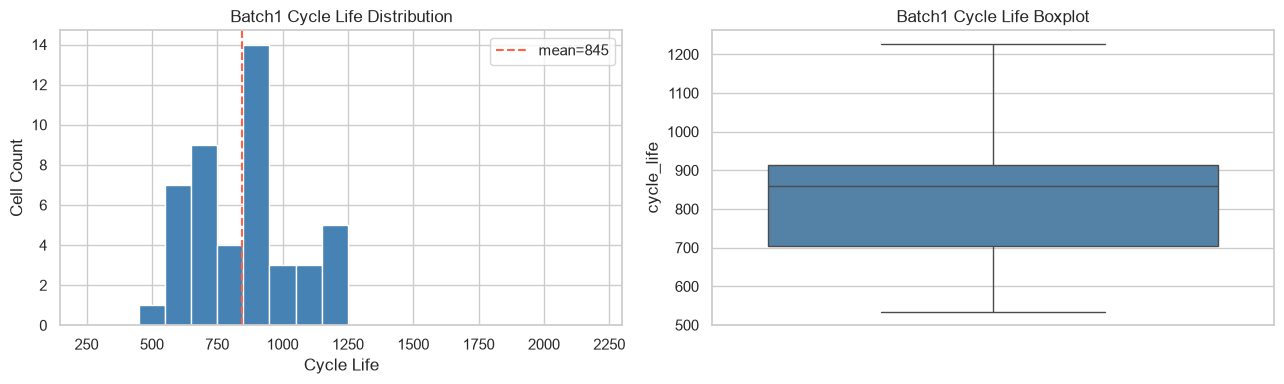

,value
cell_count,46.000
mean,844.717
median,858.500
std,184.629
min,534.000
max,1227.000
long_ratio_>1000,0.217
short_ratio_<500,0.000


IQR 기준 이상치 후보


,cell_id,cycle_life,charging_policy


In [11]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch1 질문 1 실행
# 목적: 수명 분포, 장·단수명 비율과 이상치 후보를 확인합니다.
# 입력: Batch1 셀 단위 Feature
# 결과: 히스토그램·박스플롯·수명 요약표
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch1_q1_stats, batch1_outliers = q1_cycle_life(batch_features['Batch1'], 'Batch1')

### Batch1 Q1 핵심 내용과 해석

- **핵심 내용:** Target이 있는 셀은 46개이며 평균 수명은 844.7사이클, 중앙값은 858.5사이클이다. 범위는 534~1,227사이클이고 표준편차는 184.6사이클이다.
- **장·단수명 비율:** 1,000사이클 초과 장수명 셀은 21.7%, 500사이클 미만 단수명 셀은 0%이다.
- **이상치:** IQR 기준으로 분류되는 수명 이상치 셀은 없다.
- **해석:** 중앙값이 평균보다 약간 높고 500사이클 미만 셀이 없어, 극단적인 단수명 셀보다 700~900사이클대 셀이 중심인 비교적 안정적인 분포다. 다만 1,000사이클 이상 장수명 셀이 약 5분의 1 포함되어 수명 범위는 충분히 넓다.
- **모델 시사점:** Batch1에는 500사이클 미만 사례가 없으므로 단수명 영역으로의 외삽이 제한된다. 연속 수명을 사용하는 회귀를 기본으로 하고 Batch2에서 분포 이동 성능을 반드시 평가한다.


## 질문 2. 방전용량 열화 곡선

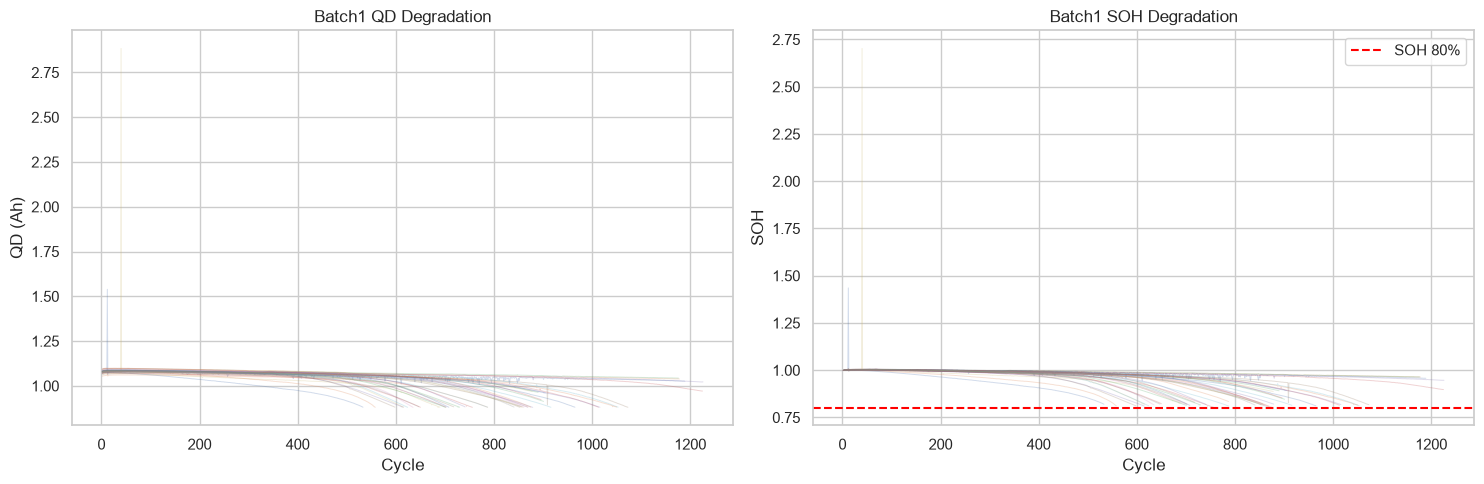

,cell_id,cycle_life,qd_slope_100,soh_slope_100,knee_cycle_candidate
count,46.0000,46.0000,46.0000,46.0000,46.0000
mean,22.5000,844.7174,-0.0000,-0.0000,773.9348
std,13.4226,184.6292,0.0001,0.0001,177.0857
min,0.0000,534.0000,-0.0003,-0.0003,51.0000
25%,11.2500,703.2500,-0.0000,-0.0000,693.2500
50%,22.5000,858.5000,-0.0000,-0.0000,839.0000
75%,33.7500,914.2500,0.0000,0.0000,886.5000
max,45.0000,1227.0000,0.0000,0.0000,1045.0000


In [12]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch1 질문 2 실행
# 목적: QD와 SOH가 일정하게 감소하는지, 후반에 가속되는지 확인합니다.
# 입력: Batch1 Summary와 Feature
# 결과: 열화 곡선·초기 기울기·Knee 후보 통계
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

q2_degradation(batch_summaries['Batch1'], batch_features['Batch1'], 'Batch1')

### Batch1 Q2 핵심 내용과 해석

- **핵심 내용:** 초기 100사이클 QD 기울기 중앙값은 약 -5.01×10⁻⁶ Ah/cycle, SOH 기울기 중앙값은 약 -4.64×10⁻⁶/cycle이다. Knee point 후보 중앙값은 839사이클이다.
- **관계:** 초기 SOH 기울기와 수명의 상관계수는 0.182로 약하지만, Knee point 후보와 수명의 상관계수는 0.591로 더 크다.
- **해석:** 초기 100사이클에서 용량 감소가 매우 작아 초기 기울기 하나만으로 수명을 명확히 구분하기 어렵다. 반면 급격한 열화가 시작되는 시점이 늦을수록 최종 수명이 긴 경향이 나타난다.
- **주의:** Knee point는 이동평균과 2차 변화량으로 계산한 후보값이므로 실제 곡선과 함께 확인해야 한다.
- **모델 시사점:** 전체 수명 이후에 확인되는 Knee 시점은 입력 피처로 사용하지 않고, 예측 시점에 알 수 있는 초기 100사이클 SOH 변화량·기울기만 후보로 사용한다.


## 질문 3. ΔQ(V) 곡선

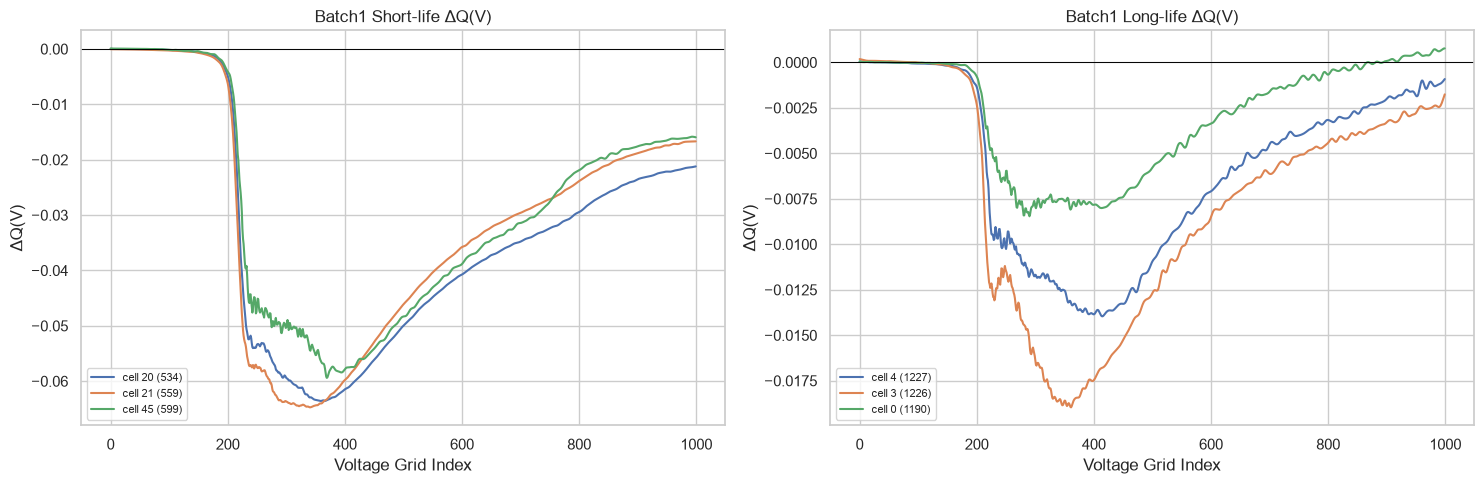

,corr_with_cycle_life
delta_q_std,-0.894
delta_q_log_variance,-0.886
delta_q_min,0.882
delta_q_mean,0.854
delta_q_abs_mean,-0.854
delta_q_variance,-0.838
delta_q_max,0.264


In [13]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch1 질문 3 실행
# 목적: 장수·단수 셀의 ΔQ(V) 형태와 ΔQ 통계값의 수명 연관성을 확인합니다.
# 입력: Batch1 ΔQ Feature
# 결과: 대표 ΔQ 곡선·수명 상관계수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch1_q3_corr = q3_delta_q(batch_features['Batch1'], 'Batch1')

### Batch1 Q3 핵심 내용과 해석

- **핵심 내용:** 수명과 가장 강한 관계를 보인 ΔQ 피처는 `delta_q_std`(r=-0.894), `delta_q_log_variance`(r=-0.886), `delta_q_min`(r=0.882)이다.
- **형태 차이:** 단수명 방향의 셀일수록 ΔQ(V)의 변동 폭과 분산이 커지고, 장수명 셀일수록 변화량이 상대적으로 작고 안정적인 형태를 보인다.
- **해석:** 초기 10→100사이클 사이 방전곡선이 크게 변하는 셀은 최종 수명이 짧은 경향이 강하다. 단순 초기용량보다 곡선의 변화 형태가 초기 열화 정보를 더 잘 담고 있다.
- **주의:** `delta_q_std`, `delta_q_min`, `delta_q_log_variance`는 서로 높은 상관을 보이므로 모두 동시에 사용할 필요는 없다.
- **모델 시사점:** 강한 ΔQ 피처 중 중복을 줄이기 위해 `delta_q_log_variance`를 대표 피처로 우선 사용하고, 다른 ΔQ 통계값은 제거 실험으로 비교한다.


## 질문 4. 충전 조건과 수명

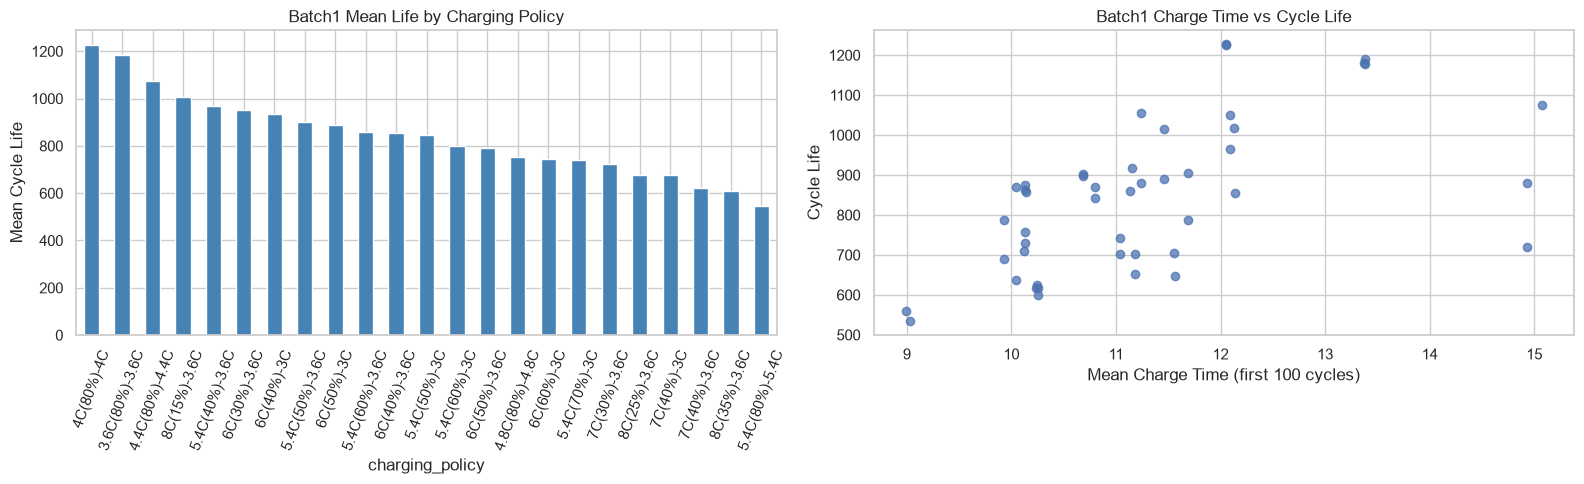

,mean_life,median_life,std_life,cell_count
charging_policy,,,,
4C(80%)-4C,1226.5,1226.5,0.71,2
3.6C(80%)-3.6C,1182.0,1179.0,7.00,3
4.4C(80%)-4.4C,1074.0,1074.0,NaN,1
8C(15%)-3.6C,1008.5,1008.5,60.10,2
5.4C(40%)-3.6C,966.5,966.5,123.74,2
6C(30%)-3.6C,952.5,952.5,86.97,2
6C(40%)-3C,935.5,935.5,115.26,2
5.4C(50%)-3.6C,899.5,899.5,3.54,2
6C(50%)-3C,888.5,888.5,40.31,2


,correlation
first_c_rate,-0.580
chargetime_mean_100,0.577
tavg_mean_100,-0.482
switch_soc,0.235
soh_slope_100,0.182
second_c_rate,-0.096


In [14]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch1 질문 4 실행
# 목적: 충전 정책, C-rate, 충전시간과 수명의 관계를 확인합니다.
# 입력: Batch1 Feature
# 결과: 정책별 수명·표본 수·충전 변수 상관
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch1_policy = q4_charging(batch_features['Batch1'], 'Batch1')

### Batch1 Q4 핵심 내용과 해석

- **핵심 내용:** 평균 수명이 가장 높은 정책은 `4C(80%)-4C`로 1,226.5사이클(n=2), 가장 낮은 정책은 `5.4C(80%)-5.4C`로 546.5사이클(n=2)이다.
- **상관관계:** 1단계 C-rate와 수명의 상관계수는 -0.580, 초기 평균 충전시간과 수명은 0.577, 평균온도와 수명은 -0.482이다.
- **해석:** 1단계 충전속도가 높고 충전시간이 짧을수록 수명이 짧아지는 경향이 관찰된다. 빠른 충전과 높은 온도가 함께 나타날 수 있어 각 변수의 독립적인 효과로 단정할 수는 없다.
- **주의:** 정책별 표본 수가 1~3개 수준인 경우가 많아 정책 평균의 불확실성이 크다.
- **모델 시사점:** 정책 문자열보다 C-rate·전환 SOC·충전시간을 수치 피처로 분리한다. 표본이 적으므로 정책별 평균만으로 모델을 설계하지 않는다.


## 질문 5. 수명과 관련된 초기 신호

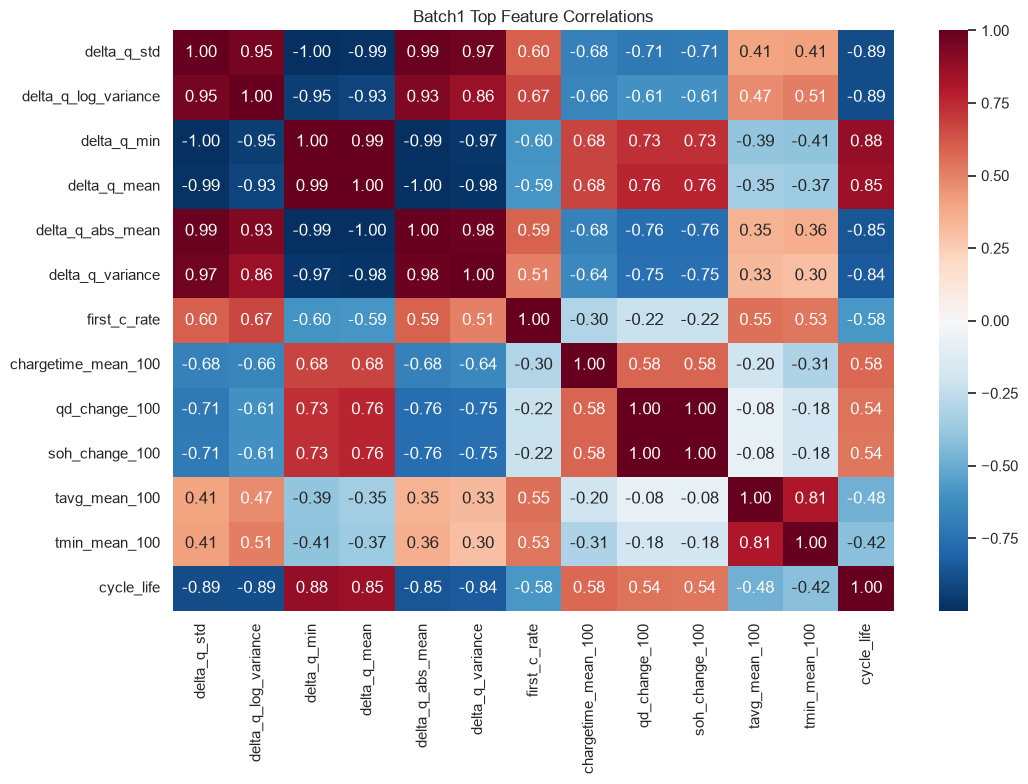

,corr_with_cycle_life
delta_q_std,-0.894
delta_q_log_variance,-0.886
delta_q_min,0.882
delta_q_mean,0.854
delta_q_abs_mean,-0.854
delta_q_variance,-0.838
first_c_rate,-0.580
chargetime_mean_100,0.577
qd_change_100,0.540
soh_change_100,0.537


In [15]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch1 질문 5 실행
# 목적: 초기 피처 중 수명과 강하게 연결되는 신호와 중복 신호를 찾습니다.
# 입력: Batch1 Feature
# 결과: 상관 히트맵·피처 순위
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch1_q5_corr = q5_correlations(batch_features['Batch1'], 'Batch1')

### Batch1 Q5 핵심 내용과 해석

- **강한 신호:** `delta_q_std`(r=-0.894), `delta_q_log_variance`(r=-0.886), `delta_q_min`(r=0.882), `delta_q_mean`(r=0.854)이 수명과 가장 강한 관계를 보였다.
- **추가 신호:** `first_c_rate`(r=-0.580), `chargetime_mean_100`(r=0.577), `qd_change_100`(r=0.540)도 중간 정도의 관계를 보였다.
- **해석:** Batch1에서는 ΔQ(V) 통계 피처가 충전 조건이나 단순 QD 평균보다 수명을 더 잘 구분한다.
- **다중공선성:** QD 기울기와 SOH 기울기(r≈1.000), QD 변화량과 SOH 변화량(r≈1.000), 여러 ΔQ 통계값(r>0.98)이 거의 같은 정보를 가진다.
- **모델 시사점:** 다중공선성이 매우 높으므로 ΔQ·QD·SOH 계열에서 대표 피처만 남기고 Ridge 규제를 기본 모델로 사용한다.


# Batch2 질문 5개 결과

아래 다섯 결과를 실행한 뒤 각 해석 셀의 대괄호 부분을 실제 관찰값으로 바꿉니다.

## 질문 1. Cycle Life 분포

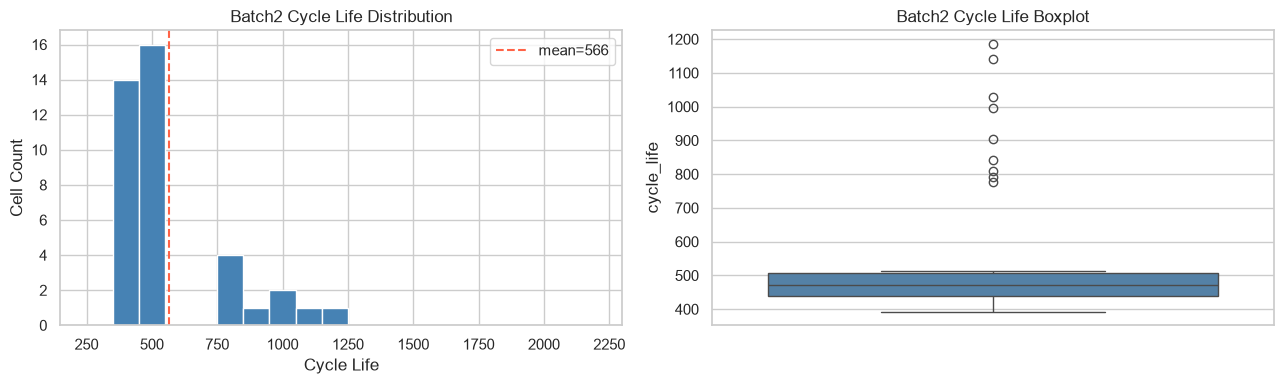

,value
cell_count,39.000
mean,565.744
median,472.000
std,222.202
min,392.000
max,1186.000
long_ratio_>1000,0.077
short_ratio_<500,0.718


IQR 기준 이상치 후보


,cell_id,cycle_life,charging_policy
7,7,777.0,4.8C(80%)-4.8C-newstructure
8,8,904.0,5.2C(58%)-4C-newstructure
9,9,791.0,5.6C(26%)-4.5C-newstructure
32,32,809.0,4.8C(80%)-4.8C-newstructure
33,33,1140.0,5.2C(58%)-4C-newstructure
34,34,1186.0,5.6C(26%)-4.5C-newstructure
43,43,1029.0,4.8C(80%)-4.8C-newstructure
44,44,841.0,5.2C(58%)-4C-newstructure
45,45,997.0,5.6C(26%)-4.5C-newstructure


In [16]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch2 질문 1 실행
# 목적: 수명 분포, 장·단수명 비율과 이상치 후보를 확인합니다.
# 입력: Batch2 셀 단위 Feature
# 결과: 히스토그램·박스플롯·수명 요약표
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch2_q1_stats, batch2_outliers = q1_cycle_life(batch_features['Batch2'], 'Batch2')

### Batch2 Q1 핵심 내용과 해석

- **핵심 내용:** 전체 47개 셀 중 `cycle_life`가 있는 셀은 39개이고 8개는 Target이 누락됐다. 유효 셀의 평균 수명은 565.7사이클, 중앙값은 472.0사이클이며 범위는 392~1,186사이클이다.
- **장·단수명 비율:** 유효 셀 기준 1,000사이클 초과 장수명 셀은 7.7%, 500사이클 미만 단수명 셀은 71.8%이다.
- **이상치:** IQR 기준 상단 이상치 후보는 9개이며, 777~1,186사이클 범위의 `newstructure` 충전 정책 셀에 집중되어 있다.
- **해석:** 대부분이 500사이클 미만에 몰려 있으나 일부 `newstructure` 셀이 매우 긴 수명을 보여 강한 오른쪽 꼬리 분포가 형성된다. 이 셀들은 오류라기보다 다른 실험 구조나 정책의 영향일 가능성이 있으므로 제거하면 안 된다.
- **모델 시사점:** Batch1과 Target 분포가 크게 달라 Batch2는 외부 일반화 시험에 적합하다. 범위 차이를 고려해 MAPE와 MAE를 함께 보고 극단 셀 오차를 별도 분석한다.


## 질문 2. 방전용량 열화 곡선

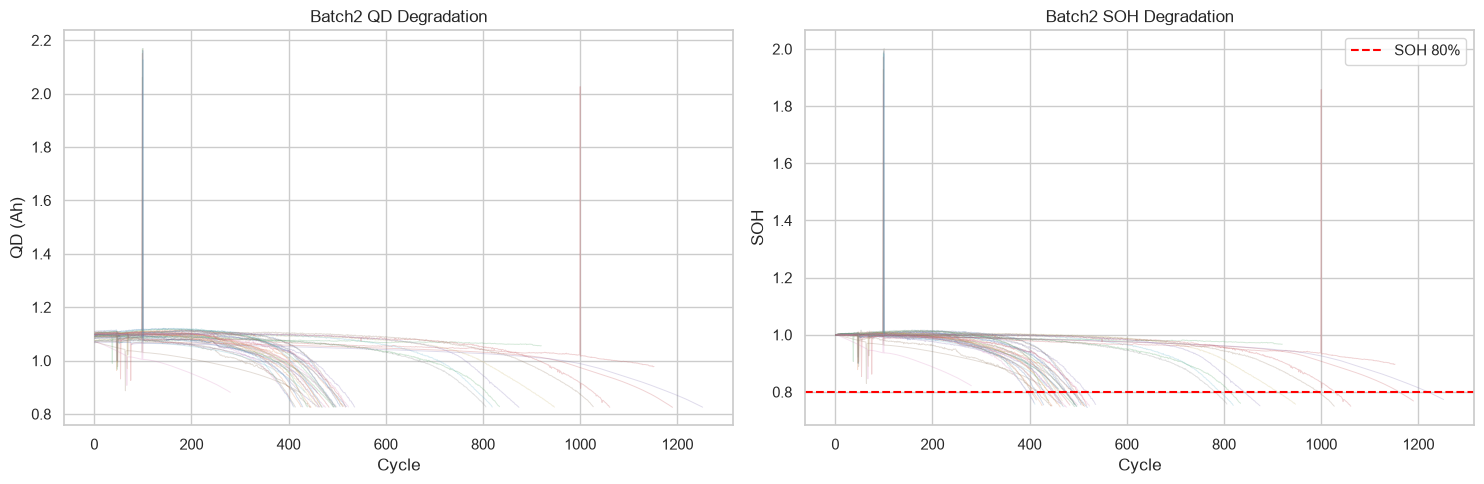

,cell_id,cycle_life,qd_slope_100,soh_slope_100,knee_cycle_candidate
count,47.0000,39.0000,47.0000,47.0000,47.0000
mean,23.0000,565.7436,0.0001,0.0001,394.6809
std,13.7113,222.2016,0.0002,0.0002,278.9373
min,0.0000,392.0000,-0.0002,-0.0002,57.0000
25%,11.5000,439.5000,-0.0000,-0.0000,101.5000
50%,23.0000,472.0000,0.0000,0.0000,455.0000
75%,34.5000,508.5000,0.0001,0.0001,494.5000
max,46.0000,1186.0000,0.0006,0.0006,1244.0000


In [17]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch2 질문 2 실행
# 목적: QD와 SOH가 일정하게 감소하는지, 후반에 가속되는지 확인합니다.
# 입력: Batch2 Summary와 Feature
# 결과: 열화 곡선·초기 기울기·Knee 후보 통계
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

q2_degradation(batch_summaries['Batch2'], batch_features['Batch2'], 'Batch2')

### Batch2 Q2 핵심 내용과 해석

- **핵심 내용:** 초기 100사이클 QD 기울기 중앙값은 약 2.34×10⁻⁵ Ah/cycle, SOH 기울기 중앙값은 약 2.14×10⁻⁵/cycle이다. Knee point 후보 중앙값은 468사이클이다.
- **관계:** SOH 기울기와 수명의 상관계수는 -0.442, Knee point 후보와 수명은 0.357이다.
- **해석:** 초기 기울기 중앙값이 양수인 것은 초기 활성화·형성 효과나 측정 구조로 인해 초반 용량이 약간 증가하는 셀이 있음을 뜻한다. Batch1보다 Knee 후보가 훨씬 이르고 최종 수명도 짧아 전반적인 열화 진행이 빠르다.
- **주의:** 초기 양의 기울기를 정상적인 수명 증가로 해석하면 안 되며, 초기 형성 구간과 실제 열화 구간을 분리해서 확인해야 한다.
- **모델 시사점:** 초기 기울기의 방향이 Batch1과 달라 단독 핵심 피처로 사용하기 어렵다. 형성 구간 영향을 줄이는 ΔQ 피처와 함께 사용하고 제거 실험을 수행한다.


## 질문 3. ΔQ(V) 곡선

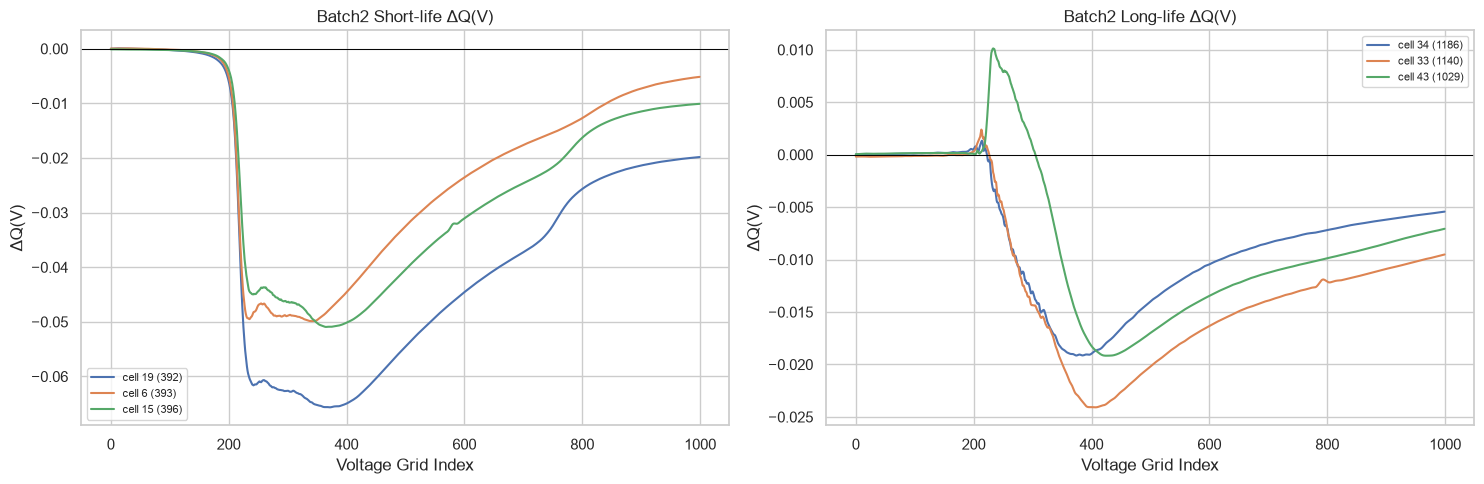

,corr_with_cycle_life
delta_q_log_variance,-0.902
delta_q_std,-0.835
delta_q_min,0.819
delta_q_mean,0.767
delta_q_abs_mean,-0.765
delta_q_variance,-0.733
delta_q_max,0.498


In [18]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch2 질문 3 실행
# 목적: 장수·단수 셀의 ΔQ(V) 형태와 ΔQ 통계값의 수명 연관성을 확인합니다.
# 입력: Batch2 ΔQ Feature
# 결과: 대표 ΔQ 곡선·수명 상관계수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch2_q3_corr = q3_delta_q(batch_features['Batch2'], 'Batch2')

### Batch2 Q3 핵심 내용과 해석

- **핵심 내용:** 가장 강한 ΔQ 피처는 `delta_q_log_variance`(r=-0.902), `delta_q_std`(r=-0.835), `delta_q_min`(r=0.819)이다.
- **형태 차이:** ΔQ(V)의 분산과 표준편차가 클수록 최종 수명이 짧고, 장수명 셀은 상대적으로 작은 곡선 변화를 보인다.
- **해석:** Batch1과 마찬가지로 ΔQ 로그분산의 상관 방향이 음수이고 크기도 매우 강하다. Batch가 달라도 초기 곡선 변화량이 수명을 구분하는 패턴이 유지된다.
- **주의:** `cycle_life`가 누락된 8개 셀은 이 상관계수 계산에서 제외됐다.
- **모델 시사점:** `delta_q_log_variance`가 Batch1과 같은 방향으로 재현되므로 Batch 간 일반화 가능성이 높은 핵심 피처로 채택한다.


## 질문 4. 충전 조건과 수명

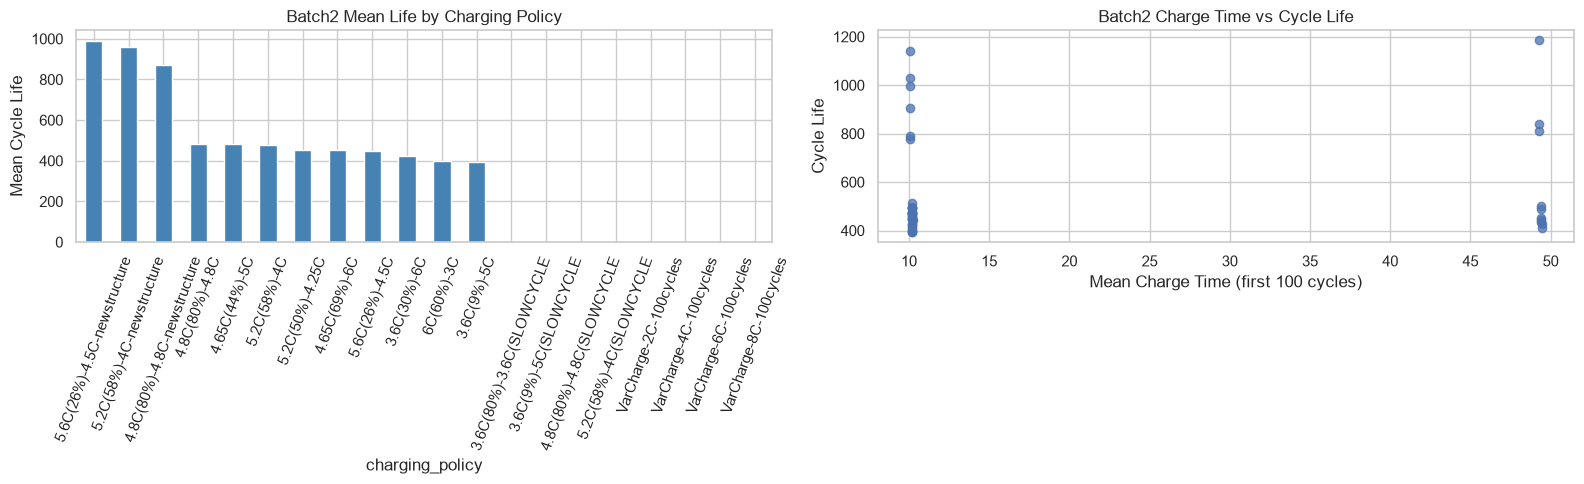

,mean_life,median_life,std_life,cell_count
charging_policy,,,,
5.6C(26%)-4.5C-newstructure,991.33,997.0,197.56,3
5.2C(58%)-4C-newstructure,961.67,904.0,157.62,3
4.8C(80%)-4.8C-newstructure,871.67,809.0,137.19,3
4.8C(80%)-4.8C,483.60,492.0,30.32,5
4.65C(44%)-5C,482.50,482.5,23.33,2
5.2C(58%)-4C,477.75,483.0,18.46,4
5.2C(50%)-4.25C,454.00,449.0,20.92,5
4.65C(69%)-6C,452.00,452.0,11.31,2
5.6C(26%)-4.5C,448.50,446.0,29.13,6


,correlation
soh_slope_100,-0.442
tavg_mean_100,0.425
first_c_rate,0.191
second_c_rate,-0.116
switch_soc,0.116
chargetime_mean_100,0.087


In [19]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch2 질문 4 실행
# 목적: 충전 정책, C-rate, 충전시간과 수명의 관계를 확인합니다.
# 입력: Batch2 Feature
# 결과: 정책별 수명·표본 수·충전 변수 상관
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch2_policy = q4_charging(batch_features['Batch2'], 'Batch2')

### Batch2 Q4 핵심 내용과 해석

- **핵심 내용:** 평균 수명이 가장 높은 정책은 `5.6C(26%)-4.5C-newstructure`로 991.3사이클(n=3), 가장 낮은 정책은 `3.6C(9%)-5C`로 394.5사이클(n=2)이다.
- **상관관계:** 평균온도와 수명의 상관계수는 0.425, SOH 초기 기울기와 수명은 -0.442이다. 충전시간과 수명은 0.087로 매우 약하다.
- **해석:** Batch1과 달리 단순 C-rate 또는 충전시간만으로 수명을 설명하기 어렵다. `newstructure` 정책 셀들이 긴 수명을 보여 충전속도뿐 아니라 셀 구조나 실험 조건의 영향이 함께 존재할 가능성이 크다.
- **주의:** Batch2 내부 상관 방향이 Batch1과 다른 변수들이 있으므로 인과관계로 해석하면 안 된다.
- **모델 시사점:** 충전시간·C-rate의 관계가 Batch1과 다르므로 충전 조건 피처는 보조 변수로 취급하고, `newstructure` 여부와 정책 미지 범주를 처리한다.


## 질문 5. 수명과 관련된 초기 신호

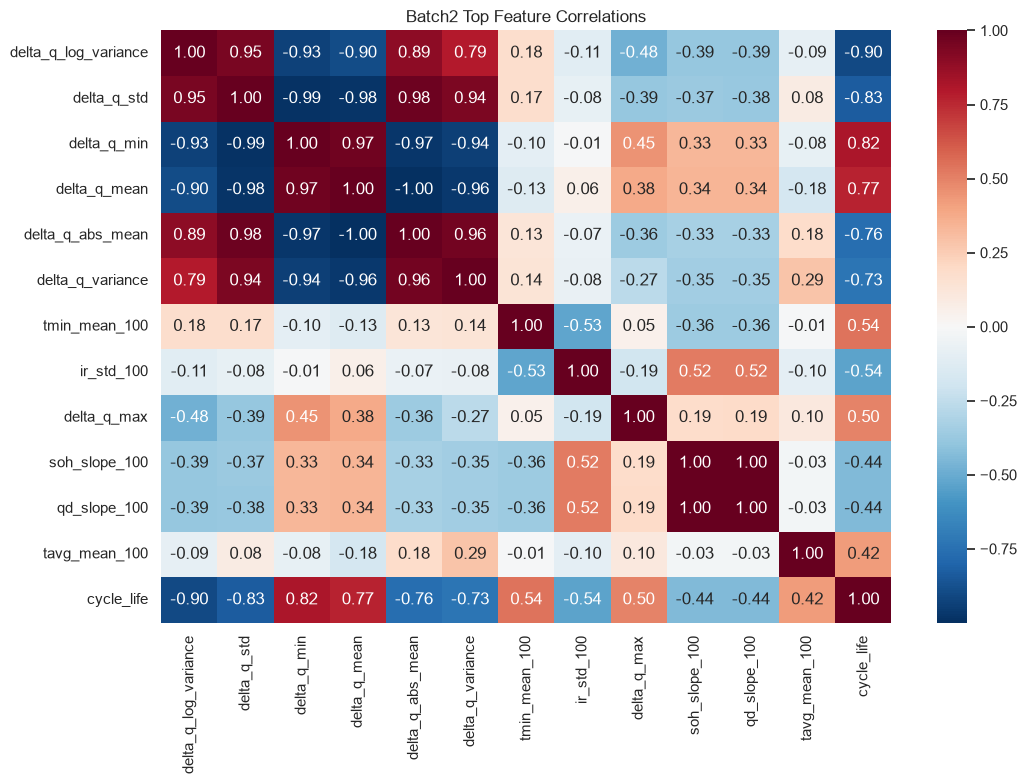

,corr_with_cycle_life
delta_q_log_variance,-0.902
delta_q_std,-0.835
delta_q_min,0.819
delta_q_mean,0.767
delta_q_abs_mean,-0.765
delta_q_variance,-0.733
tmin_mean_100,0.540
ir_std_100,-0.536
delta_q_max,0.498
soh_slope_100,-0.442


In [20]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch2 질문 5 실행
# 목적: 초기 피처 중 수명과 강하게 연결되는 신호와 중복 신호를 찾습니다.
# 입력: Batch2 Feature
# 결과: 상관 히트맵·피처 순위
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch2_q5_corr = q5_correlations(batch_features['Batch2'], 'Batch2')

### Batch2 Q5 핵심 내용과 해석

- **강한 신호:** `delta_q_log_variance`(r=-0.902), `delta_q_std`(r=-0.835), `delta_q_min`(r=0.819), `delta_q_mean`(r=0.767)이 가장 강했다.
- **추가 신호:** 초기 최저온도 평균(r=0.540), IR 표준편차(r=-0.536), ΔQ 최댓값(r=0.498)이 중간 정도의 관계를 보였다.
- **해석:** Batch2에서도 ΔQ 피처가 상위 신호를 차지해 Batch1에서 발견한 관계가 재현된다. 반면 충전시간이나 C-rate의 관계는 약해 Batch 종속적인 피처일 가능성이 있다.
- **다중공선성:** 충전시간 평균과 표준편차(r≈1.000), QD·SOH 변화량과 기울기(r≈1.000), 여러 ΔQ 통계값(r>0.98)이 중복된다.
- **모델 시사점:** ΔQ 계열을 주 피처로 사용하고 온도·IR 피처는 Batch별 안정성을 검증한 뒤 선택한다. 중복 피처는 Ridge 또는 명시적 제거로 제어한다.


# Batch3 질문 5개 결과

아래 다섯 결과를 실행한 뒤 각 해석 셀의 대괄호 부분을 실제 관찰값으로 바꿉니다.

## 질문 1. Cycle Life 분포

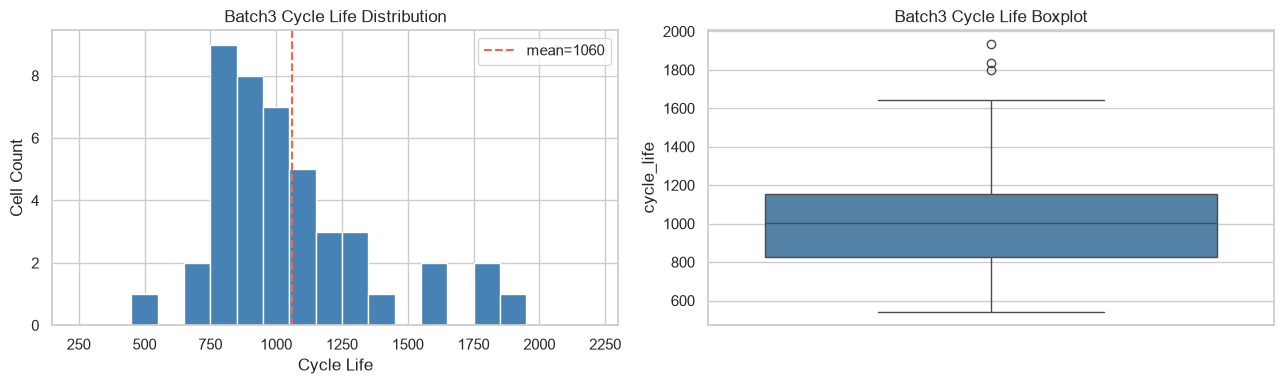

,value
cell_count,44.000
mean,1059.659
median,1005.500
std,313.870
min,541.000
max,1935.000
long_ratio_>1000,0.523
short_ratio_<500,0.000


IQR 기준 이상치 후보


,cell_id,cycle_life,charging_policy
7,7,1836.0,4.8C(80%)-4.8C-newstructure
38,38,1935.0,5C(67%)-4C-newstructure
45,45,1801.0,4.8C(80%)-4.8C-newstructure


In [21]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch3 질문 1 실행
# 목적: 수명 분포, 장·단수명 비율과 이상치 후보를 확인합니다.
# 입력: Batch3 셀 단위 Feature
# 결과: 히스토그램·박스플롯·수명 요약표
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch3_q1_stats, batch3_outliers = q1_cycle_life(batch_features['Batch3'], 'Batch3')

### Batch3 Q1 핵심 내용과 해석

- **핵심 내용:** 전체 46개 셀 중 `cycle_life`가 있는 셀은 44개이고 2개는 Target이 누락됐다. 평균 수명은 1,059.7사이클, 중앙값은 1,005.5사이클이며 범위는 541~1,935사이클이다.
- **장·단수명 비율:** 유효 셀 기준 1,000사이클 초과 장수명 셀은 52.3%, 500사이클 미만 단수명 셀은 0%이다.
- **이상치:** IQR 기준 상단 이상치 후보는 셀 7(1,836), 셀 38(1,935), 셀 45(1,801)이다. 모두 `newstructure` 계열 정책이다.
- **해석:** 세 Batch 중 수명 수준이 가장 높고 절반 이상이 1,000사이클을 초과한다. 상단 이상치 후보도 실제 장수명 실험 결과일 가능성이 있으므로 제거 대상이 아니라 별도 분석 대상이다.
- **모델 시사점:** Batch3은 장수명 영역이 넓어 학습 범위 밖 장수명 예측 성능을 평가하는 추가 일반화 세트로 사용한다.


## 질문 2. 방전용량 열화 곡선

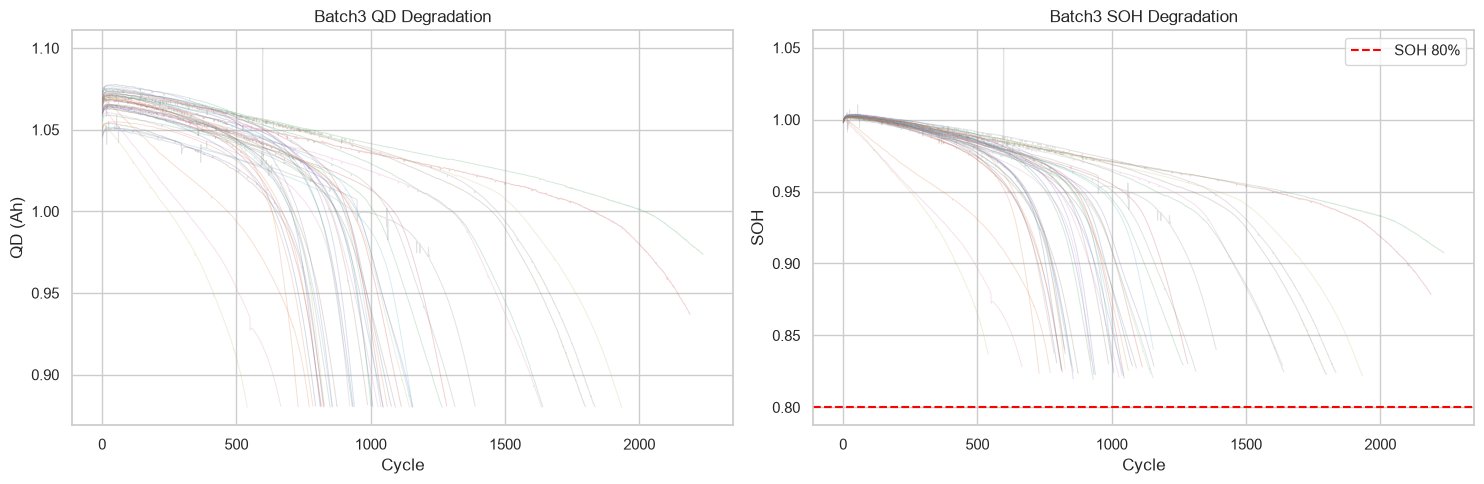

,cell_id,cycle_life,qd_slope_100,soh_slope_100,knee_cycle_candidate
count,46.0000,44.0000,46.0000,46.0000,46.0000
mean,22.5000,1059.6591,-0.0000,-0.0000,1010.3913
std,13.4226,313.8697,0.0000,0.0000,327.3037
min,0.0000,541.0000,-0.0002,-0.0002,515.0000
25%,11.2500,828.0000,-0.0000,-0.0000,810.0000
50%,22.5000,1005.5000,-0.0000,-0.0000,955.5000
75%,33.7500,1155.2500,-0.0000,-0.0000,1129.2500
max,45.0000,1935.0000,0.0000,0.0000,1926.0000


In [22]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch3 질문 2 실행
# 목적: QD와 SOH가 일정하게 감소하는지, 후반에 가속되는지 확인합니다.
# 입력: Batch3 Summary와 Feature
# 결과: 열화 곡선·초기 기울기·Knee 후보 통계
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

q2_degradation(batch_summaries['Batch3'], batch_features['Batch3'], 'Batch3')

### Batch3 Q2 핵심 내용과 해석

- **핵심 내용:** 초기 100사이클 QD 기울기 중앙값은 약 -4.61×10⁻⁶ Ah/cycle, SOH 기울기 중앙값은 약 -4.33×10⁻⁶/cycle이다. Knee point 후보 중앙값은 986.5사이클이다.
- **관계:** 초기 SOH 기울기와 수명의 상관계수는 0.333이고, Knee point 후보와 수명은 0.929로 매우 강하다.
- **해석:** Batch3은 초기 용량 감소가 작고 급격한 열화가 시작되는 시점도 가장 늦다. Knee가 늦게 나타나는 셀일수록 최종 수명이 긴 관계가 매우 뚜렷하다.
- **주의:** Knee point는 전체 수명 곡선을 이용해 계산하므로 초기 100사이클만 사용하는 예측 모델의 입력 피처로 직접 사용하면 데이터 누수가 발생한다.
- **모델 시사점:** Knee 시점은 분석 Target으로만 활용하고 모델 입력에서는 제외한다. 초기 SOH 기울기는 Batch별 부호가 달라 보조 피처로 평가한다.


## 질문 3. ΔQ(V) 곡선

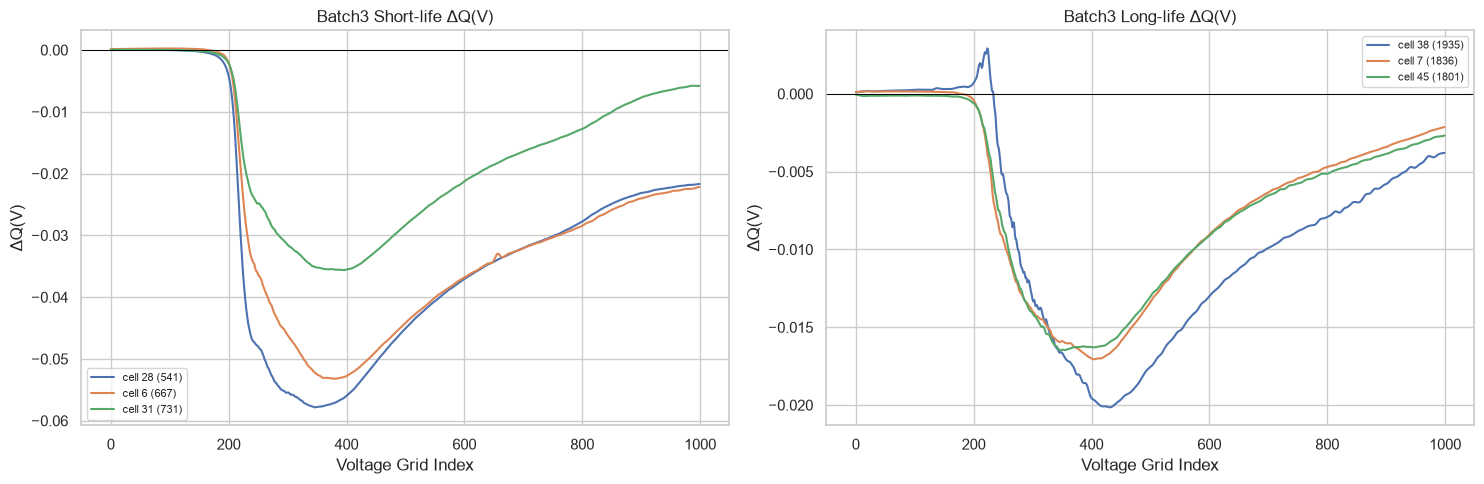

,corr_with_cycle_life
delta_q_log_variance,-0.702
delta_q_min,0.692
delta_q_std,-0.673
delta_q_mean,0.639
delta_q_abs_mean,-0.629
delta_q_variance,-0.590
delta_q_max,0.408


In [23]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch3 질문 3 실행
# 목적: 장수·단수 셀의 ΔQ(V) 형태와 ΔQ 통계값의 수명 연관성을 확인합니다.
# 입력: Batch3 ΔQ Feature
# 결과: 대표 ΔQ 곡선·수명 상관계수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch3_q3_corr = q3_delta_q(batch_features['Batch3'], 'Batch3')

### Batch3 Q3 핵심 내용과 해석

- **핵심 내용:** 가장 강한 ΔQ 피처는 `delta_q_log_variance`(r=-0.702), `delta_q_min`(r=0.692), `delta_q_std`(r=-0.673)이다.
- **형태 차이:** 단수명 방향의 셀은 초기 10→100사이클 사이 곡선 변화와 분산이 크고, 장수명 셀은 변화가 작고 안정적이다.
- **해석:** Batch1·2보다 상관 크기는 낮지만 부호와 피처 순위가 대체로 유지된다. ΔQ 로그분산은 세 Batch에서 모두 수명과 음의 관계를 보이는 일관된 신호다.
- **주의:** ΔQ 통계값끼리 상관이 높으므로 대표 피처를 선별해야 한다.
- **모델 시사점:** `delta_q_log_variance`는 세 Batch에서 모두 같은 방향을 보여 최우선 핵심 피처로 선택한다.


## 질문 4. 충전 조건과 수명

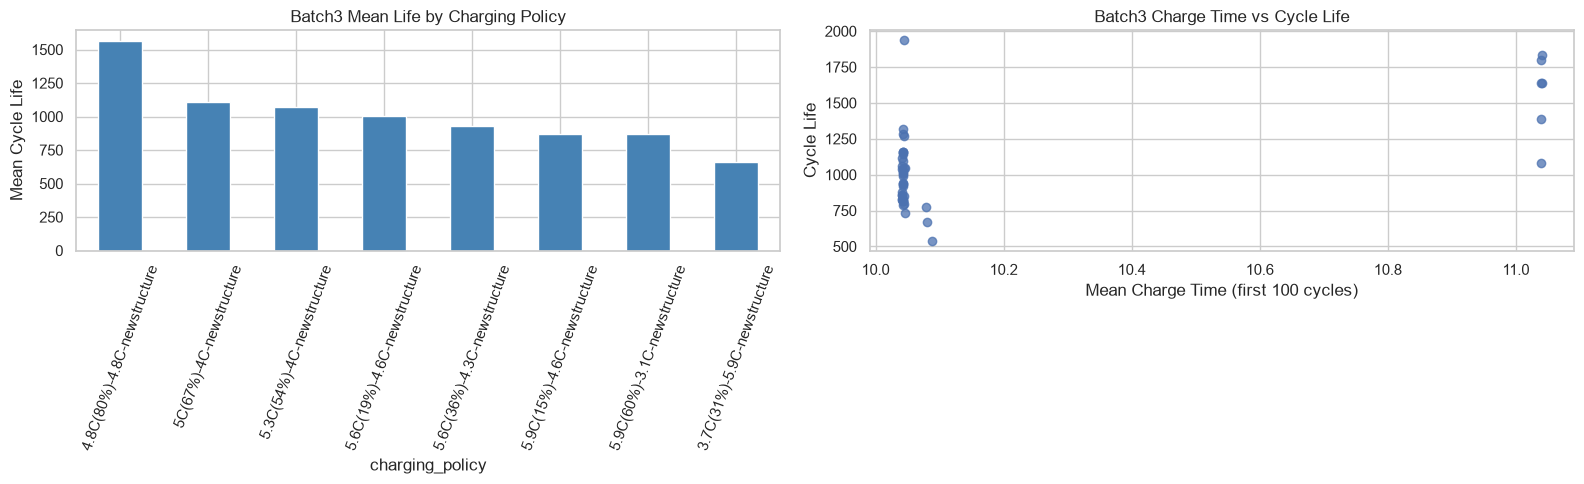

,mean_life,median_life,std_life,cell_count
charging_policy,,,,
4.8C(80%)-4.8C-newstructure,1564.17,1640.0,285.72,8
5C(67%)-4C-newstructure,1105.71,1009.0,402.91,7
5.3C(54%)-4C-newstructure,1074.38,1051.0,129.67,8
5.6C(19%)-4.6C-newstructure,1001.38,1038.0,174.56,8
5.6C(36%)-4.3C-newstructure,930.88,890.5,135.02,8
5.9C(15%)-4.6C-newstructure,867.00,867.0,12.73,2
5.9C(60%)-3.1C-newstructure,866.50,866.5,191.63,2
3.7C(31%)-5.9C-newstructure,660.00,667.0,115.66,3


,correlation
chargetime_mean_100,0.637
switch_soc,0.541
soh_slope_100,0.333
first_c_rate,-0.083
second_c_rate,-0.043
tavg_mean_100,-0.022


In [24]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch3 질문 4 실행
# 목적: 충전 정책, C-rate, 충전시간과 수명의 관계를 확인합니다.
# 입력: Batch3 Feature
# 결과: 정책별 수명·표본 수·충전 변수 상관
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch3_policy = q4_charging(batch_features['Batch3'], 'Batch3')

### Batch3 Q4 핵심 내용과 해석

- **핵심 내용:** 평균 수명이 가장 높은 정책은 `4.8C(80%)-4.8C-newstructure`로 1,564.2사이클(n=6), 가장 낮은 정책은 `3.7C(31%)-5.9C-newstructure`로 660.0사이클(n=3)이다.
- **상관관계:** 초기 평균 충전시간과 수명의 상관계수는 0.637, 전환 SOC는 0.541이다. 1단계 C-rate(r=-0.083)와 평균온도(r=-0.022)의 단순 관계는 매우 약하다.
- **해석:** Batch3에서는 C-rate 숫자 자체보다 충전시간과 전환 SOC가 수명 차이를 더 잘 설명한다. 충전 정책을 하나의 문자열로만 사용하기보다 단계별 조건으로 분해할 필요가 있다.
- **주의:** 정책별 표본 수가 2~8개로 여전히 작아 평균 수명 차이를 인과관계로 단정할 수 없다.
- **모델 시사점:** 정책 문자열의 직접 One-Hot보다 충전시간·전환 SOC 같은 수치형 조건을 우선하고, 문자열 정책은 미지 범주 처리와 함께 보조로 사용한다.


## 질문 5. 수명과 관련된 초기 신호

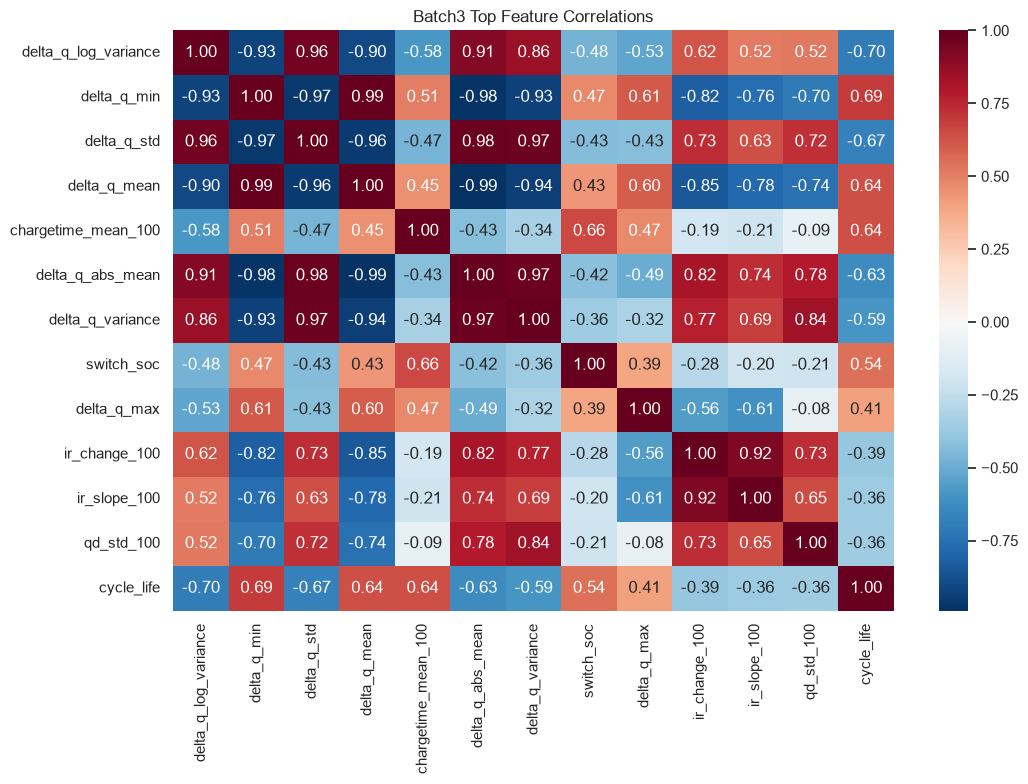

,corr_with_cycle_life
delta_q_log_variance,-0.702
delta_q_min,0.692
delta_q_std,-0.673
delta_q_mean,0.639
chargetime_mean_100,0.637
delta_q_abs_mean,-0.629
delta_q_variance,-0.590
switch_soc,0.541
delta_q_max,0.408
ir_change_100,-0.390


In [25]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch3 질문 5 실행
# 목적: 초기 피처 중 수명과 강하게 연결되는 신호와 중복 신호를 찾습니다.
# 입력: Batch3 Feature
# 결과: 상관 히트맵·피처 순위
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch3_q5_corr = q5_correlations(batch_features['Batch3'], 'Batch3')

### Batch3 Q5 핵심 내용과 해석

- **강한 신호:** `delta_q_log_variance`(r=-0.702), `delta_q_min`(r=0.692), `delta_q_std`(r=-0.673), `delta_q_mean`(r=0.639)이 상위에 위치했다.
- **추가 신호:** 초기 평균 충전시간(r=0.637), 전환 SOC(r=0.541), ΔQ 최댓값(r=0.408), IR 변화량(r=-0.390)이 관계를 보였다.
- **해석:** Batch3에서도 ΔQ 피처의 방향이 Batch1·2와 일치하며, 충전시간도 중요한 신호로 나타난다. IR 변화량은 보조 피처로 검토할 수 있지만 ΔQ보다 관계가 약하다.
- **다중공선성:** QD 기울기와 SOH 기울기(r≈1.000), QD 변화량과 SOH 변화량(r≈1.000), 여러 ΔQ 통계값(r>0.99)이 중복된다.
- **모델 시사점:** ΔQ 대표 피처와 충전시간을 우선 검토하며, IR 변화량은 Batch 간 부호가 달라 제거 실험 대상으로 둔다.


# Batch 1·2·3 비교

이 섹션이 Day 1의 핵심입니다. 값이 가장 좋은 Batch를 선택하는 것이 아니라, 세 Batch에서 **방향이 일관된 피처**와 **분포가 달라지는 피처**를 구분합니다.

## 비교 1. Cycle Life와 열화 특성

,cell_count,mean_life,median_life,std_life,min_life,max_life,mean_qd_slope,mean_soh_slope,median_knee,long_ratio_>1000,short_ratio_<500
batch,,,,,,,,,,,
Batch1,46,844.717,858.5,184.629,534.0,1227.0,-0.0,-0.0,839.0,0.217,0.000
Batch2,47,565.744,472.0,222.202,392.0,1186.0,0.0,0.0,455.0,0.064,0.596
Batch3,46,1059.659,1005.5,313.870,541.0,1935.0,-0.0,-0.0,955.5,0.500,0.000


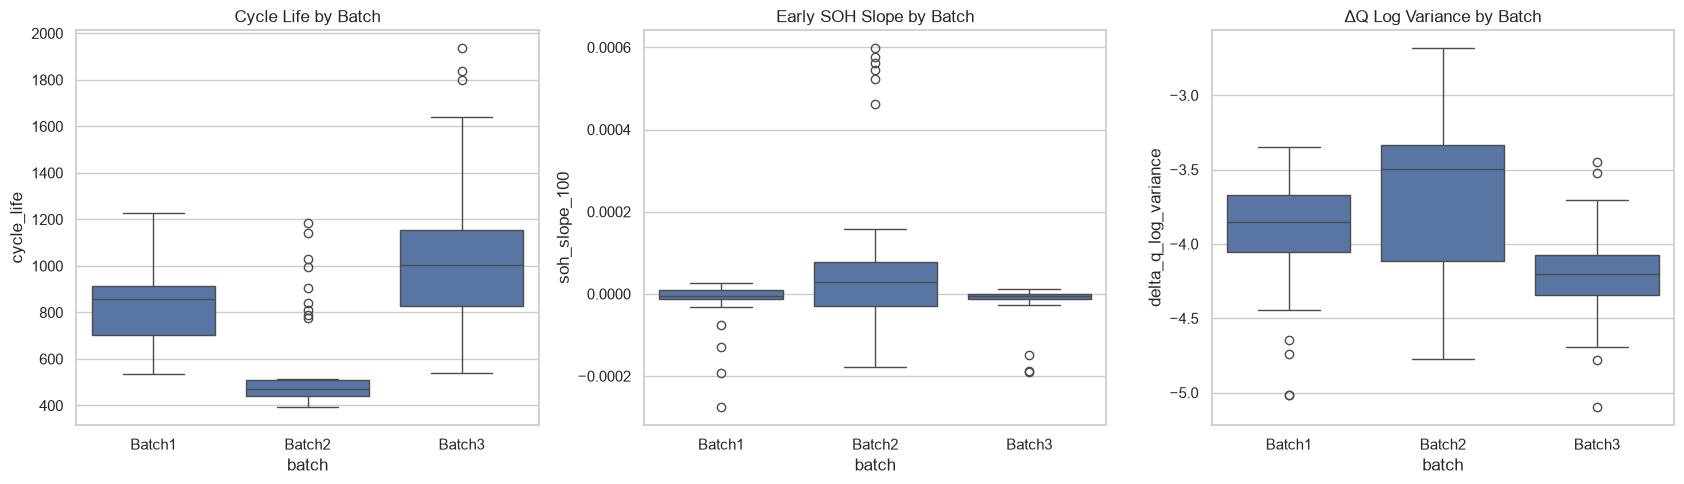

In [26]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: Batch별 수명·열화 비교
# 목적: 세 Batch의 Target shift와 초기 열화 분포 차이를 한 표와 그림에서 확인합니다.
# 입력: all_features
# 결과: 수명·기울기·Knee·ΔQ Batch 비교
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

batch_life_comparison = (
    all_features.groupby('batch')
    .agg(
        cell_count=('cell_id', 'count'),
        mean_life=('cycle_life', 'mean'),
        median_life=('cycle_life', 'median'),
        std_life=('cycle_life', 'std'),
        min_life=('cycle_life', 'min'),
        max_life=('cycle_life', 'max'),
        mean_qd_slope=('qd_slope_100', 'mean'),
        mean_soh_slope=('soh_slope_100', 'mean'),
        median_knee=('knee_cycle_candidate', 'median'),
    )
)

long_ratio = all_features.groupby('batch')['cycle_life'].apply(lambda x: (x > 1000).mean())
short_ratio = all_features.groupby('batch')['cycle_life'].apply(lambda x: (x < 500).mean())
batch_life_comparison['long_ratio_>1000'] = long_ratio
batch_life_comparison['short_ratio_<500'] = short_ratio

display(batch_life_comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.boxplot(data=all_features, x='batch', y='cycle_life', ax=axes[0])
sns.boxplot(data=all_features, x='batch', y='soh_slope_100', ax=axes[1])
sns.boxplot(data=all_features, x='batch', y='delta_q_log_variance', ax=axes[2])
axes[0].set_title('Cycle Life by Batch')
axes[1].set_title('Early SOH Slope by Batch')
axes[2].set_title('ΔQ Log Variance by Batch')
plt.tight_layout()
plt.show()

### 비교 1 핵심 내용과 시사점

- **Target shift:** 평균 수명은 Batch3(1,059.7) > Batch1(844.7) > Batch2(565.7) 순이다. 유효 Target 기준 Batch2의 71.8%는 500사이클 미만이고, Batch3의 52.3%는 1,000사이클을 초과한다.
- **열화 차이:** 초기 SOH 기울기 중앙값은 Batch1 -4.64×10⁻⁶, Batch2 2.14×10⁻⁵, Batch3 -4.33×10⁻⁶/cycle로 Batch2의 방향이 다르다. Knee 후보 중앙값도 Batch2 468, Batch1 839, Batch3 986.5사이클로 큰 차이가 있다.
- **해석:** Batch2는 수명과 Knee 시점이 가장 짧고 초기 형성 효과로 보이는 양의 기울기가 나타난다. Batch3는 수명이 가장 길고 Knee도 가장 늦다. 세 Batch는 동일한 모집단으로 보기 어려운 분포 이동을 보인다.
- **모델 시사점:** 셀 단위로 Batch1에서 학습·검증하고, Batch2를 외부 테스트, Batch3를 추가 일반화 테스트로 분리한다. Batch별 성능 차이를 함께 보고 한 Batch에만 맞춘 피처를 피한다.


## 비교 2. 피처와 수명의 상관관계 일관성

batch,Batch1,Batch2,Batch3,mean_abs_corr,min_abs_corr,sign_consistent
feature,,,,,,
delta_q_log_variance,-0.886,-0.902,-0.702,0.830,0.702,True
delta_q_std,-0.894,-0.835,-0.673,0.800,0.673,True
delta_q_min,0.882,0.819,0.692,0.797,0.692,True
delta_q_mean,0.854,0.767,0.639,0.753,0.639,True
delta_q_abs_mean,-0.854,-0.765,-0.629,0.749,0.629,True
delta_q_variance,-0.838,-0.733,-0.590,0.720,0.590,True
chargetime_mean_100,0.577,0.087,0.637,0.434,0.087,True
delta_q_max,0.264,0.498,0.408,0.390,0.264,True
qd_change_100,0.540,-0.216,0.253,0.336,0.216,False


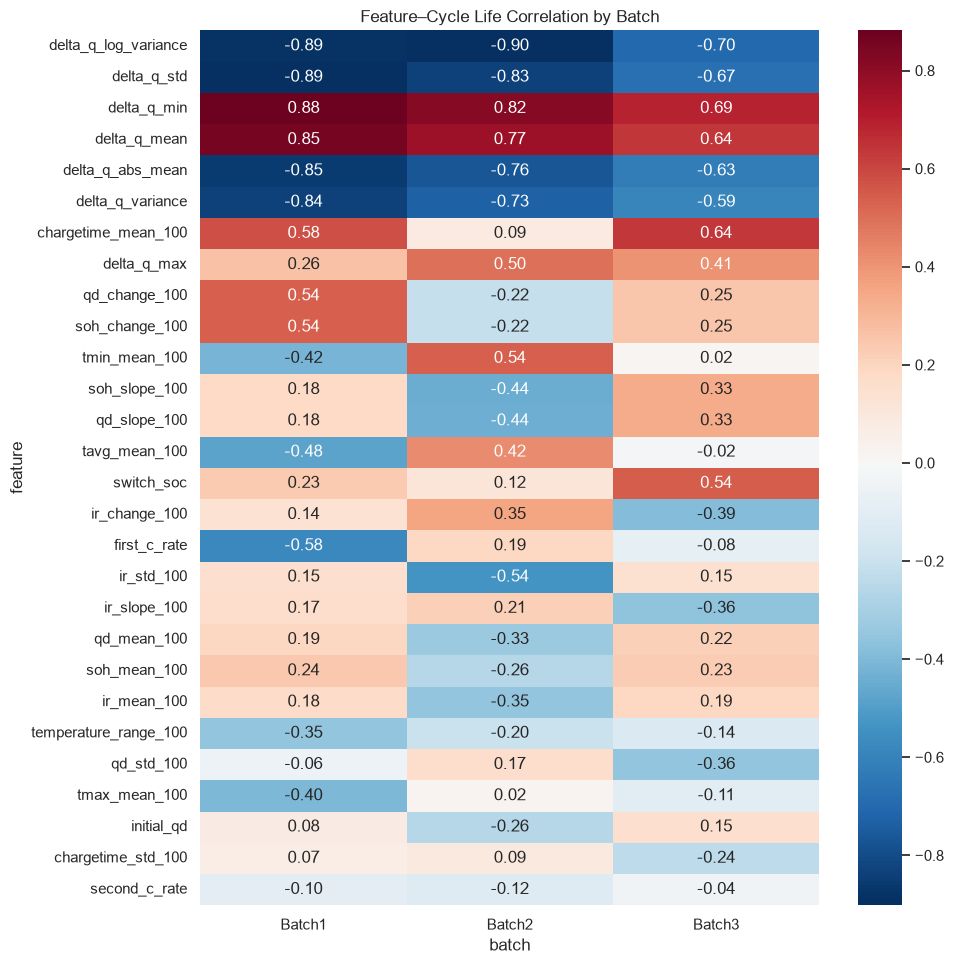

In [27]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 피처 상관관계의 Batch 일관성 비교
# 목적: 한 Batch에서만 강한 피처와 세 Batch에서 방향이 같은 피처를 구분합니다.
# 입력: all_features 숫자 피처
# 결과: Batch×피처 상관표와 히트맵
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

NON_FEATURES = {
    'cell_id', 'cycle_life', 'observed_cycles', 'knee_cycle_candidate',
    'delta_index_10', 'delta_index_100'
}

candidate_features = [
    column for column in all_features.select_dtypes(include=np.number).columns
    if column not in NON_FEATURES
]

correlation_rows = []
for batch_name, group in all_features.groupby('batch'):
    for feature in candidate_features:
        pair = group[[feature, 'cycle_life']].dropna()
        correlation = pair[feature].corr(pair['cycle_life']) if len(pair) >= 3 else np.nan
        correlation_rows.append({
            'batch': batch_name,
            'feature': feature,
            'correlation': correlation,
            'missing_ratio': group[feature].isna().mean(),
        })

correlation_long = pd.DataFrame(correlation_rows)
correlation_table = correlation_long.pivot(index='feature', columns='batch', values='correlation')
correlation_table['mean_abs_corr'] = correlation_table.abs().mean(axis=1)
correlation_table['min_abs_corr'] = correlation_table[['Batch1','Batch2','Batch3']].abs().min(axis=1)
correlation_table['sign_consistent'] = correlation_table[['Batch1','Batch2','Batch3']].apply(
    lambda row: len(set(np.sign(row.dropna()))) <= 1, axis=1
)
correlation_table = correlation_table.sort_values('mean_abs_corr', ascending=False)

display(correlation_table.round(3))

plt.figure(figsize=(10, max(6, len(candidate_features) * 0.35)))
sns.heatmap(
    correlation_table[['Batch1','Batch2','Batch3']],
    cmap='RdBu_r', center=0, annot=True, fmt='.2f'
)
plt.title('Feature–Cycle Life Correlation by Batch')
plt.tight_layout()
plt.show()

### 비교 2 핵심 내용과 시사점

- **일관된 피처:** ΔQ(V) 계열이 가장 안정적이다. `delta_q_log_variance`의 상관계수는 Batch1 -0.886, Batch2 -0.902, Batch3 -0.702이며, `delta_q_std`는 -0.894/-0.835/-0.673, `delta_q_min`은 0.882/0.819/0.692로 세 Batch에서 방향과 크기가 유지된다. `delta_q_max`도 0.264/0.498/0.408로 방향이 일치한다.
- **불안정한 피처:** `qd_change_100`은 0.540/-0.216/0.253, `soh_slope_100`은 0.182/-0.442/0.333, `tavg_mean_100`은 -0.482/0.425/-0.022, `first_c_rate`는 -0.580/0.191/-0.083으로 Batch별 부호가 바뀐다. IR 변화량·기울기도 Batch3에서 방향이 달라진다.
- **해석:** 한 Batch에서만 높은 상관을 보이는 QD/SOH·온도·IR·C-rate 피처는 실험 조건이나 Batch 구성에 의존할 가능성이 높다. ΔQ 계열은 서로 다른 수명 분포에서도 같은 방향을 유지해 일반화 가능성이 가장 높다.
- **모델 시사점:** `delta_q_log_variance`를 대표 핵심 피처로 우선 사용한다. 서로 강하게 중복되는 ΔQ 통계값은 하나씩 추가·제거하며 검증하고, 불안정한 피처는 보조 후보로 두고 제거 실험을 수행한다.


## 비교 3. 충전 정책의 Batch 간 중복

In [28]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 충전 정책의 Batch 중복 확인
# 목적: 정책 문자열이 다른 Batch에도 존재하는지 확인해 범주형 피처의 일반화 위험을 평가합니다.
# 입력: charging_policy와 batch
# 결과: 정책별 등장 Batch 수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

policy_presence = pd.crosstab(
    all_features['charging_policy'],
    all_features['batch']
)
policy_presence['batch_count'] = (policy_presence > 0).sum(axis=1)
policy_presence = policy_presence.sort_values(['batch_count','Batch1','Batch2','Batch3'], ascending=False)
display(policy_presence)

print('세 Batch 모두에 존재하는 정책 수:', (policy_presence['batch_count'] == 3).sum())
print('한 Batch에만 존재하는 정책 수:', (policy_presence['batch_count'] == 1).sum())

batch,Batch1,Batch2,Batch3,batch_count
charging_policy,,,,
4.8C(80%)-4.8C,2,5,0,2
6C(60%)-3C,2,2,0,2
4.8C(80%)-4.8C-newstructure,0,3,8,2
3.6C(80%)-3.6C,3,0,0,1
4C(80%)-4C,2,0,0,1
5.4C(40%)-3.6C,2,0,0,1
5.4C(50%)-3.6C,2,0,0,1
5.4C(50%)-3C,2,0,0,1
5.4C(60%)-3.6C,2,0,0,1


세 Batch 모두에 존재하는 정책 수: 0
한 Batch에만 존재하는 정책 수: 45


### 비교 3 핵심 내용과 시사점

- **관찰:** 전체 48개 충전 정책 중 세 Batch에 모두 공통인 정책은 0개이다. 한 Batch에만 존재하는 정책은 45개이고, 두 Batch에 걸쳐 나타나는 정책은 3개이다.
- **해석:** 정책 문자열은 Batch 정보와 거의 결합돼 있어 문자열 자체를 One-Hot Encoding하면 새로운 Batch의 미지 정책을 처리하기 어렵고 Batch를 간접적으로 암기할 위험이 있다.
- **모델 시사점:** 정책 문자열보다 `first_c_rate`, `switch_soc`, `second_c_rate`, 초기 평균 충전시간처럼 물리적으로 비교 가능한 수치 피처를 우선 사용한다. 정책 문자열을 사용할 경우 `handle_unknown="ignore"`를 적용하고 제거 실험으로 기여도를 확인한다.


# 선별한 변수와 이유

아래 코드는 세 Batch의 상관 방향, 최소 상관 크기, 결측률을 기준으로 1차 후보를 만듭니다. 자동 선별 결과를 그대로 확정하지 말고 물리적 의미와 데이터 누수 여부를 함께 검토합니다.

In [29]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 1차 변수 자동 선별
# 목적: 상관 방향·최소 상관 크기·결측률로 검토 우선순위를 만듭니다.
# 입력: 상관표와 결측률
# 결과: 선택 후보와 선택 이유 표
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

missing_by_feature = (
    all_features[candidate_features]
    .isna()
    .mean()
)

selection_table = correlation_table.copy()
selection_table['overall_missing_ratio'] = missing_by_feature
selection_table['auto_select'] = (
    selection_table['sign_consistent']
    & (selection_table['min_abs_corr'] >= 0.20)
    & (selection_table['overall_missing_ratio'] <= 0.20)
)

selection_table['reason'] = np.where(
    selection_table['auto_select'],
    '세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%',
    'Batch별 관계 변화·낮은 상관·결측률 중 하나를 추가 검토'
)

display(selection_table.round(3))
print('자동 선별 후보')
display(selection_table[selection_table['auto_select']].round(3))

batch,Batch1,Batch2,Batch3,mean_abs_corr,min_abs_corr,sign_consistent,overall_missing_ratio,auto_select,reason
feature,,,,,,,,,
delta_q_log_variance,-0.886,-0.902,-0.702,0.830,0.702,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_std,-0.894,-0.835,-0.673,0.800,0.673,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_min,0.882,0.819,0.692,0.797,0.692,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_mean,0.854,0.767,0.639,0.753,0.639,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_abs_mean,-0.854,-0.765,-0.629,0.749,0.629,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_variance,-0.838,-0.733,-0.590,0.720,0.590,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
chargetime_mean_100,0.577,0.087,0.637,0.434,0.087,True,0.000,False,Batch별 관계 변화·낮은 상관·결측률 중 하나를 추가 검토
delta_q_max,0.264,0.498,0.408,0.390,0.264,True,0.000,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
qd_change_100,0.540,-0.216,0.253,0.336,0.216,False,0.000,False,Batch별 관계 변화·낮은 상관·결측률 중 하나를 추가 검토


자동 선별 후보


batch,Batch1,Batch2,Batch3,mean_abs_corr,min_abs_corr,sign_consistent,overall_missing_ratio,auto_select,reason
feature,,,,,,,,,
delta_q_log_variance,-0.886,-0.902,-0.702,0.830,0.702,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_std,-0.894,-0.835,-0.673,0.800,0.673,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_min,0.882,0.819,0.692,0.797,0.692,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_mean,0.854,0.767,0.639,0.753,0.639,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_abs_mean,-0.854,-0.765,-0.629,0.749,0.629,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_variance,-0.838,-0.733,-0.590,0.720,0.590,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"
delta_q_max,0.264,0.498,0.408,0.390,0.264,True,0.0,True,"세 Batch에서 방향이 일관되고 최소 |상관|≥0.20, 결측률≤20%"


## 다중공선성 확인

In [30]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 다중공선성 확인
# 목적: 선택 후보끼리 거의 같은 정보를 담는 피처 쌍을 찾아 중복을 줄입니다.
# 입력: 선택 후보 피처
# 결과: |상관| 0.90 이상 피처 쌍
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

selected_candidates = selection_table[selection_table['auto_select']].index.tolist()

high_corr_pairs = []
if len(selected_candidates) >= 2:
    feature_corr = all_features[selected_candidates].corr().abs()
    for i, feature_1 in enumerate(selected_candidates):
        for feature_2 in selected_candidates[i + 1:]:
            value = feature_corr.loc[feature_1, feature_2]
            if value >= 0.90:
                high_corr_pairs.append({
                    'feature_1': feature_1,
                    'feature_2': feature_2,
                    'abs_correlation': value,
                })

high_corr_pairs = pd.DataFrame(high_corr_pairs)
display(high_corr_pairs if not high_corr_pairs.empty else pd.DataFrame({'result':['|상관| 0.90 이상 쌍 없음']}))

,feature_1,feature_2,abs_correlation
0,delta_q_log_variance,delta_q_std,0.946974
1,delta_q_log_variance,delta_q_min,0.938246
2,delta_q_log_variance,delta_q_mean,0.907756
3,delta_q_log_variance,delta_q_abs_mean,0.905683
4,delta_q_std,delta_q_min,0.991267
5,delta_q_std,delta_q_mean,0.983158
6,delta_q_std,delta_q_abs_mean,0.984848
7,delta_q_std,delta_q_variance,0.940628
8,delta_q_min,delta_q_mean,0.983269
9,delta_q_min,delta_q_abs_mean,0.981156


## 최종 변수 선정표

| 변수 | 선택 여부 | 선택·제외 이유 | Batch1/Batch2/Batch3 수명 상관 | 모델 처리 |
|---|---|---|---|---|
| `delta_q_log_variance` | 핵심 선택 | 세 Batch에서 가장 강하고 일관된 음의 관계 | -0.886 / -0.902 / -0.702 | 결측 중앙값 대체, StandardScaler |
| `soh_slope_100` | 보조·제거 실험 | 초기 상대 열화 속도지만 Batch2에서 부호 반전 | 0.182 / -0.442 / 0.333 | 단독 사용 금지, 제거 실험 |
| `qd_change_100` | 보조·제거 실험 | Batch2에서 부호 반전, SOH 변화량과 거의 중복 | 0.540 / -0.216 / 0.253 | SOH 계열 중 하나만 선택 |
| `ir_slope_100` | 보조·제거 실험 | Batch3에서 부호 반전 | 0.169 / 0.213 / -0.363 | 이상치 확인 후 비교 |
| `chargetime_mean_100` | 보조 선택 | 방향은 같지만 Batch2 관계가 매우 약함 | 0.577 / 0.087 / 0.637 | 결측 중앙값 대체, StandardScaler |
| `tavg_mean_100` | 제외 우선 | Batch별 부호가 바뀌고 Batch3 관계가 거의 없음 | -0.482 / 0.425 / -0.022 | 온도 범위 피처와 비교 |
| `temperature_range_100` | 보조 선택 | 세 Batch에서 음의 방향은 유지되나 관계가 약함 | -0.353 / -0.205 / -0.140 | StandardScaler |
| `first_c_rate` | 제외 우선 | Batch별 부호가 바뀌어 안정성이 낮음 | -0.580 / 0.191 / -0.083 | 충전시간·SOC와 비교 |
| `charging_policy` | 제외 우선 | 세 Batch 공통 정책 0개, Batch 암기 위험 | 공통 0개 / 단일 Batch 정책 45개 | 필요 시 OneHot unknown 처리 |

**최종 1차 입력안:** `delta_q_log_variance`를 핵심으로 사용하고, `chargetime_mean_100`, `temperature_range_100`을 보조 피처로 추가한다. QD/SOH·IR 관련 피처는 하나씩 추가하는 제거 실험으로 Batch 외부 성능 향상 여부를 확인한다.

> `cycle_life`, 전체 관측 사이클 수, Knee 시점, 최종 EOL 시점처럼 예측 시점에 알 수 없는 정보는 입력 피처로 사용하지 않는다.


# EDA Insight → 모델 설계 전략

## Target과 문제 유형

### 1차 제안: Regression

- Target: `cycle_life`
- 이유: 실제 잔여 수명을 숫자로 예측할 수 있고, 550사이클 분류 기준에서 발생할 수 있는 클래스 불균형을 피할 수 있다.
- 분류를 선택하려면 Batch별 `<550`, `≥550` 클래스 수와 F1을 반드시 확인한다.

In [31]:
# ── 이 셀의 역할 ─────────────────────────────────────────────
# 역할: 회귀·분류 선택 근거 확인
# 목적: 550사이클 기준 클래스 불균형을 확인해 분류가 타당한지 판단합니다.
# 입력: all_features의 cycle_life
# 결과: Batch별 <550·>=550 셀 수
# 실행 후 확인: 오류 없이 표·그래프가 생성되는지 확인하고 바로 아래 해석과 연결합니다.
# ──────────────────────────────────────────────────────────────

classification_balance = (
    all_features.dropna(subset=['cycle_life'])
    .assign(label=lambda data: (data['cycle_life'] >= 550).astype(int))
    .groupby(['batch', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: '<550', 1: '>=550'})
)
display(classification_balance)

label,<550,>=550
batch,,
Batch1,1,45
Batch2,30,9
Batch3,1,43


## Modeling Strategy 후보와 EDA 연결

| EDA에서 확인한 특성 | 설계 전략 | 후보 모델 |
|---|---|---|
| 세 Batch의 수명 분포가 다름 | Batch 1 내부 검증 후 Batch 2·3 외부 평가 | 모든 모델 공통 |
| 셀 수가 적고 피처 간 상관이 높음 | 단순 모델과 규제를 우선 사용 | Ridge, ElasticNet |
| ΔQ·열화 기울기와 수명이 비선형일 수 있음 | 트리 기반 모델과 비교 | RandomForest, GradientBoosting |
| 정책 문자열이 Batch마다 다를 수 있음 | C-rate 숫자화, 미지 범주 처리 | Pipeline + OneHotEncoder |
| 피처 스케일이 서로 다름 | 수치형 중앙값 대체와 표준화 | Ridge/ElasticNet Pipeline |
| 일부 ΔQ 피처가 결측될 수 있음 | 학습 데이터 중앙값으로 대체 | SimpleImputer |
| 데이터가 46개 수준으로 작을 수 있음 | 복잡한 딥러닝보다 교차검증 가능한 모델 | Ridge, RF, GradientBoosting |

### 비교할 모델

1. `DummyRegressor`: 중앙값 예측 기준선
2. `Ridge`: 다중공선성과 소표본에 대응하는 해석 가능한 기본 모델
3. `ElasticNet`: 불필요한 피처 축소 가능성 확인
4. `RandomForestRegressor`: 비선형성과 상호작용 확인
5. `GradientBoostingRegressor`: 작은 표본에서의 비선형 성능 비교

### 데이터 역할

- Batch 1: 학습, 교차검증, 내부 검증
- Batch 2: 최종 외부 테스트
- Batch 3: 추가 일반화 테스트
- 같은 셀의 사이클 행을 무작위로 나누지 않고, 셀 하나당 한 행인 피처 테이블을 사용한다.

### 평가 지표

- 주 지표: MAPE
- 보조 지표: MAE, RMSE
- 보고 항목: Train–Valid gap, Valid–Batch2 gap, Batch2–Batch3 차이

# PDF 구성 가이드

파일명: `DS-MINI-Design-{캠퍼스_X반}-{이름1+이름2}.pdf`

권장 분량은 8~12쪽입니다. 그래프 하나마다 **관찰 → 근거 → 해석 → 모델 시사점**을 붙이고, 같은 메시지의 그래프는 한 페이지에 묶습니다.

## 1쪽 — 문제 정의와 분석 목적

- 초기 100사이클로 최종 배터리 수명을 예측하는 회귀 문제
- Batch1 학습·내부 검증, Batch2 외부 테스트, Batch3 추가 일반화 평가

## 2쪽 — 데이터 구조와 품질

- Batch1 46개, Batch2 47개, Batch3 46개 셀
- Target 누락: Batch2 8개, Batch3 2개
- 전체 Summary 116,676행

## 3쪽 — Q1 수명 분포 비교

- 평균 수명: Batch3 1,059.7 > Batch1 844.7 > Batch2 565.7
- Batch2 단수명 비율 71.8%, Batch3 장수명 비율 52.3%
- 핵심 결론: Batch 간 Target shift가 커 외부 일반화 평가가 필요

## 4쪽 — Q2 열화 곡선 비교

- Knee 후보 중앙값: Batch2 468, Batch1 839, Batch3 986.5사이클
- 핵심 결론: 전체 Knee 시점은 수명과 관련되지만 예측 입력으로 사용하면 누수이므로 제외

## 5쪽 — Q3 ΔQ(V)

- `delta_q_log_variance`: -0.886 / -0.902 / -0.702
- 핵심 결론: 세 Batch에서 가장 일관된 수명 예측 후보

## 6쪽 — Q4 충전 조건

- 세 Batch 공통 정책 0개, 한 Batch 전용 정책 45개
- 핵심 결론: 정책 문자열보다 충전시간·C-rate·전환 SOC를 숫자화

## 7쪽 — Q5 상관관계와 다중공선성

- ΔQ 계열은 일관됨
- QD/SOH, 온도, IR, C-rate는 Batch별 부호 변화
- 핵심 결론: 중복 제거와 Ridge 규제 필요

## 8쪽 — Batch 비교 핵심 Insight

| 핵심 발견 | 근거 | 모델에 반영할 내용 |
|---|---|---|
| Target 분포 이동 | 평균 565.7~1,059.7사이클 | Batch 외부 평가 |
| ΔQ 피처의 일관성 | 로그분산 r=-0.886/-0.902/-0.702 | 핵심 입력 피처 |
| 충전 정책의 비중복 | 공통 0개, 단일 Batch 45개 | 정책 숫자화·문자열 제외 실험 |
| 피처 중복 | QD-SOH, ΔQ 통계 간 r>0.98 | 대표 피처 선택·Ridge |

## 9쪽 — Feature Engineering

- 핵심: `delta_q_log_variance`
- 보조: `chargetime_mean_100`, `temperature_range_100`
- 제거 실험: SOH/QD 기울기·변화량, IR 피처

## 10쪽 — Modeling Strategy

- Regression, Target=`cycle_life`
- DummyRegressor → Ridge → ElasticNet/Tree 모델 비교
- MAPE 중심, MAE·RMSE 보조
- Batch1 학습, Batch2·3 외부 평가

## PDF 작성 원칙

- 그래프 제목·축·단위·범례를 명확히 표시합니다.
- 각 페이지 하단에 한 문장 핵심 결론을 넣습니다.
- 상관관계를 인과관계로 표현하지 않습니다.
- 정책별 표본 수를 함께 표시합니다.


# DAY 1 완료 상태

- 완료: Batch 1 질문 5개 실행 및 해석 작성
- 완료: Batch 2 질문 5개 실행 및 해석 작성
- 완료: Batch 3 질문 5개 실행 및 해석 작성
- 완료: Batch별 셀 수와 결측 현황 검증
- 완료: 세 Batch 수명 분포 비교
- 완료: 세 Batch SOH·열화 속도 비교
- 완료: 세 Batch ΔQ 피처 비교
- 완료: 충전 정책 중복과 C-rate 관계 확인
- 완료: Batch별 피처 상관 방향 비교
- 완료: 다중공선성 확인
- 완료: 선택 변수와 이유 표 작성
- 완료: EDA Insight와 후보 모델 연결
- 남은 작업: 최종 PDF에 실제 그래프 삽입
- 남은 작업: 캠퍼스·반·팀원 이름을 넣어 제출 파일명 확정
